# ⚡ VoltRelay Energy — Battery-Swap Network Analysis
**Gradient Learnings Data Analytics Hackathon · 26 Sep 2026**

**Business problem:** Swaps and revenue grew, but service failures rose faster, new-rider retention fell and per-swap margin eroded.
**Goal:** find what drives failures, churn and margin erosion, separate primary vs secondary drivers, and recommend priorities.

**Notebook flow:** 1) Setup & load → 2) Data understanding → 3) Data cleaning → 4) Unit economics → 5) Q1 Performance over time → Q2 Service failures → Q3 Stations → Q4 Batteries → Q5 Pricing & partners → Q6 Retention → Conclusions & recommendations.

> *AI disclosure: this notebook was drafted with help from Claude (Anthropic); all analysis choices were reviewed by the team.*

## 1. Setup & load

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os, warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (12, 4.5)

# 👉 Put the 8 files in one folder. Option A: upload to Google Drive and mount (recommended, files are large)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = "/content/drive/MyDrive/voltrelay"   # <-- change to your folder
except ImportError:
    DATA_DIR = "./data"
print(os.listdir(DATA_DIR))

['swap_events.csv', 'batteries.csv', 'station_hourly_status.csv', 'riders.csv', 'stations.csv', 'fleet_partners.csv', 'city_daily_context.csv', 'support_tickets.csv']


In [2]:
import shutil
LOCAL = "/content/data" if os.path.exists("/content") else DATA_DIR
os.makedirs(LOCAL, exist_ok=True)

def rd(name, **kw):
    # Works with both "x.csv" and "x.csv.gz"; copies big files from Drive to local disk first (much faster)
    for fn in [name, name.replace(".csv.gz", ".csv"), name + ".gz"]:
        src = os.path.join(DATA_DIR, fn)
        if os.path.exists(src):
            dst = os.path.join(LOCAL, fn)
            if dst != src and not os.path.exists(dst): shutil.copy(src, dst)
            return pd.read_csv(dst, low_memory=False, **kw)
    raise FileNotFoundError(f"{name} not found in {DATA_DIR}: {os.listdir(DATA_DIR)}")

# Memory-light load: repeated text columns as "category", skip unused ID columns
cat_cols = ["station_id", "event_type", "tariff_code", "payment_mode", "station_firmware", "sync_mode",
            "rider_id", "battery_in_id", "battery_out_id"]
f32 = {c: "float32" for c in ["queue_wait_sec", "soc_in_pct", "soh_in_pct", "soc_out_pct", "soh_out_pct",
                               "km_since_last_swap", "list_price_inr", "discount_inr", "amount_charged_inr",
                               "energy_to_recharge_kwh"]}
swaps    = rd("swap_events.csv.gz", dtype={**{c: "category" for c in cat_cols}, **f32},
              usecols=lambda c: c not in ("event_id", "attempt_seq"))
hourly   = rd("station_hourly_status.csv.gz")
riders   = rd("riders.csv")
batt     = rd("batteries.csv")
tickets  = rd("support_tickets.csv")
stations = rd("stations.csv")
cityday  = rd("city_daily_context.csv")
partners = rd("fleet_partners.csv")

for n, d in [("swaps", swaps), ("hourly", hourly), ("riders", riders), ("batt", batt), ("tickets", tickets),
             ("stations", stations), ("cityday", cityday), ("partners", partners)]:
    print(f"{n:9s} {d.shape}  {d.memory_usage(deep=True).sum()/1e6:,.0f} MB")

swaps     (3877013, 20)  312 MB
hourly    (1487712, 14)  214 MB
riders    (20000, 12)  4 MB
batt      (6500, 13)  1 MB
tickets   (44000, 12)  10 MB
stations  (152, 22)  0 MB
cityday   (3282, 12)  0 MB
partners  (12, 12)  0 MB


## 2. Data understanding

In [3]:
print(swaps.dtypes, "\n")
display(swaps.head(3))
print("\nEvent type mix (%):"); print((swaps.event_type.value_counts(normalize=True)*100).round(2))
print("\nMissing % (swaps):"); print((swaps.isna().mean()*100).round(1).sort_values(ascending=False).head(12))

rider_id                  category
station_id                category
event_ts                       str
event_type                category
queue_wait_sec             float32
battery_in_id             category
battery_out_id            category
soc_in_pct                 float32
soh_in_pct                 float32
soc_out_pct                float32
soh_out_pct                float32
km_since_last_swap         float32
tariff_code               category
list_price_inr             float32
discount_inr               float32
amount_charged_inr         float32
payment_mode              category
energy_to_recharge_kwh     float32
station_firmware          category
sync_mode                 category
dtype: object 



,rider_id,station_id,event_ts,event_type,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,soh_in_pct,soc_out_pct,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,88.0,BAT-2W-103542,BAT-2W-102547,15.0,100.599998,98.699997,98.900002,80.400002,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,148.0,BAT-2W-105296,BAT-2W-101923,8.3,98.300003,97.300003,98.199997,66.099998,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,307.0,BAT-2W-104732,BAT-2W-102492,11.5,99.099998,99.800003,99.099998,66.599998,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime



Event type mix (%):
event_type
swap_completed               94.04
failed_no_charged_battery     3.47
abandoned_queue               1.77
cancelled_by_rider            0.43
failed_system_error           0.30
Name: proportion, dtype: float64

Missing % (swaps):
energy_to_recharge_kwh    6.0
soh_out_pct               6.0
soc_out_pct               6.0
battery_out_id            6.0
soh_in_pct                0.7
soc_in_pct                0.7
km_since_last_swap        0.7
battery_in_id             0.7
event_type                0.0
event_ts                  0.0
station_id                0.0
rider_id                  0.0
dtype: float64


In [4]:
for n, d in [("stations", stations), ("riders", riders), ("batt", batt), ("partners", partners)]:
    print(f"==== {n}"); display(d.head(3))

==== stations


,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,charger_generation,slots_2w,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,Gen1,12,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,Gen2,16,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,Gen2,16,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN


==== riders


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad


==== batt


,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0


==== partners


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,2023-04-01,10.0,NaN,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,2023-07-01,15.0,NaN,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,2023-06-01,12.0,2024-11-01,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI


## 3. Data cleaning
Each known issue is **detected → quantified → fixed**, and logged in `clean_log` so the report can cite exact numbers.

In [5]:
clean_log = []
def log(step, detail): clean_log.append((step, detail)); print(f"✅ {step}: {detail}")

# --- Parse dates
swaps["event_ts"] = pd.to_datetime(swaps["event_ts"], errors="coerce")
hourly["hour_start"] = pd.to_datetime(hourly["hour_start"], errors="coerce")
for c in ["commissioned_date", "decommissioned_date", "firmware_updated_date", "competitor_within_1_5km_since"]:
    if c in stations: stations[c] = pd.to_datetime(stations[c], errors="coerce")
for c in ["manufacture_date", "commission_date", "retired_date"]:
    if c in batt: batt[c] = pd.to_datetime(batt[c], errors="coerce")
riders["signup_date"] = pd.to_datetime(riders["signup_date"], errors="coerce")
tickets["created_ts"] = pd.to_datetime(tickets["created_ts"], errors="coerce")
cityday["date"] = pd.to_datetime(cityday["date"], errors="coerce")
for c in ["contract_start_date", "amendment_date"]:
    if c in partners: partners[c] = pd.to_datetime(partners[c], errors="coerce")
log("Parse dates", f"{swaps.event_ts.isna().sum()} unparseable event_ts")

✅ Parse dates: 0 unparseable event_ts


In [6]:
# --- 3.1 Test stations (STN-TST*): internal, zero-value transactions -> exclude
tst = swaps.station_id.astype(str).str.startswith("STN-TST")
log("Test stations", f"removed {tst.sum():,} events at {swaps.loc[tst,'station_id'].nunique()} test stations")
swaps = swaps[~tst].copy()
hourly = hourly[~hourly.station_id.astype(str).str.startswith("STN-TST")].copy()
stations_all = stations.copy()
stations = stations[~stations.station_id.astype(str).str.startswith("STN-TST")].copy()

✅ Test stations: removed 62,031 events at 2 test stations


In [7]:
# --- 3.2 Near-duplicate offline-sync retries
# A rider cannot complete (or fail) the same kind of attempt twice at the same station within 3 minutes.
# Rule: same rider + station + event_type, <= 180 s after the previous event, and at least one of the pair
# was synced via offline_batch -> the later row is a sync retry and is dropped.
swaps = swaps.sort_values(["rider_id", "station_id", "event_ts"]).reset_index(drop=True)
def same_prev(col):
    a = swaps[col].cat.codes.to_numpy() if hasattr(swaps[col], "cat") else pd.factorize(swaps[col])[0]
    out = np.zeros(len(a), bool); out[1:] = a[1:] == a[:-1]; return out
gap = swaps.event_ts.diff().dt.total_seconds().fillna(1e9).to_numpy()
off = swaps.sync_mode.astype(str).eq("offline_batch").to_numpy()
off_prev = np.zeros(len(off), bool); off_prev[1:] = off[:-1]
dup = same_prev("rider_id") & same_prev("station_id") & same_prev("event_type") & (gap <= 180) & (off | off_prev)
idx = np.where(dup)[0][:3]
if len(idx):
    print("Example duplicate pairs (evidence):")
    display(swaps.iloc[np.sort(np.r_[idx, idx - 1])][["rider_id", "station_id", "event_ts", "event_type",
            "battery_in_id", "battery_out_id", "sync_mode", "amount_charged_inr"]])
    bi = swaps.battery_in_id.astype(str).to_numpy()
    print("Share of pairs with identical battery_in_id:", round((bi[np.where(dup)[0]] == bi[np.where(dup)[0] - 1]).mean() * 100, 1), "%")
log("Near-duplicates", f"removed {dup.sum():,} offline-sync retries ({dup.mean()*100:.3f}% of events)")
swaps = swaps[~dup].reset_index(drop=True)

Example duplicate pairs (evidence):


,rider_id,station_id,event_ts,event_type,battery_in_id,battery_out_id,sync_mode,amount_charged_inr
1800,RD-1000005,STN-DEL-046,2024-02-02 18:51:40,swap_completed,BAT-2W-103524,BAT-2W-104701,realtime,60.0
1801,RD-1000005,STN-DEL-046,2024-02-02 18:53:40,swap_completed,BAT-2W-102730,BAT-2W-106176,offline_batch,60.0
1851,RD-1000005,STN-DEL-046,2024-04-11 17:56:45,swap_completed,BAT-2W-100905,BAT-2W-100880,realtime,60.0
1852,RD-1000005,STN-DEL-046,2024-04-11 17:59:44,swap_completed,BAT-2W-100950,BAT-2W-103829,offline_batch,60.0
2043,RD-1000005,STN-DEL-046,2024-11-29 20:46:44,swap_completed,BAT-2W-100299,BAT-2W-100396,realtime,65.0
2044,RD-1000005,STN-DEL-046,2024-11-29 20:48:30,swap_completed,BAT-2W-105245,BAT-2W-103855,offline_batch,65.0


Share of pairs with identical battery_in_id: 0.0 %
✅ Near-duplicates: removed 1,370 offline-sync retries (0.036% of events)


✅ Timezone bug: shifted 141,213 events at v3.2.0 stations by +5h30m


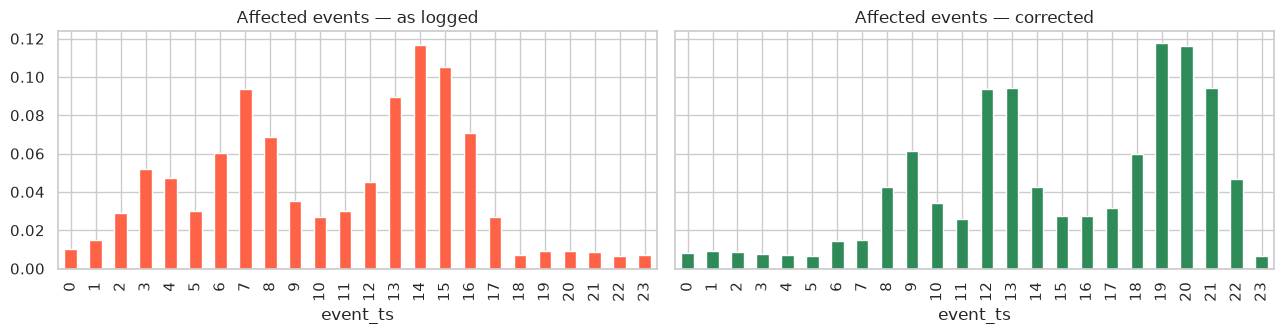

In [8]:
# --- 3.3 Firmware v3.2.0 timezone bug: 10 Mar - 14 Apr 2025, timestamps logged 5h30m early -> shift forward
fw = swaps.station_firmware.astype(str).str.contains("3.2.0", regex=False)
lo, hi = pd.Timestamp("2025-03-10") - pd.Timedelta(hours=5, minutes=30), pd.Timestamp("2025-04-15")
bug = fw & swaps.event_ts.between(lo, hi, inclusive="left")
swaps["ts_fixed"] = bug
swaps.loc[bug, "event_ts"] = swaps.loc[bug, "event_ts"] + pd.Timedelta(hours=5, minutes=30)
log("Timezone bug", f"shifted {bug.sum():,} events at v3.2.0 stations by +5h30m")

# Evidence plot: hour-of-day profile of affected rows before vs after fix
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
(swaps.loc[bug, "event_ts"] - pd.Timedelta(hours=5, minutes=30)).dt.hour.value_counts(normalize=True).sort_index().plot.bar(ax=ax[0], color="tomato", title="Affected events — as logged")
swaps.loc[bug, "event_ts"].dt.hour.value_counts(normalize=True).sort_index().plot.bar(ax=ax[1], color="seagreen", title="Affected events — corrected")
plt.tight_layout(); plt.show()

In [9]:
# --- 3.4 Sensor outliers
km = swaps.km_since_last_swap
neg = km < 0
cap = km[km >= 0].quantile(0.999)
big = km > cap
swaps.loc[neg | big, "km_since_last_swap"] = np.nan
log("km outliers", f"{neg.sum():,} negative + {big.sum():,} > p99.9 ({cap:.0f} km) set to NaN (odometer resets)")

for c in ["soc_in_pct", "soh_in_pct", "soc_out_pct", "soh_out_pct"]:
    n = (swaps[c] > 100).sum(); swaps[c] = swaps[c].clip(upper=100)
    log(f"{c} > 100", f"{n:,} readings clipped to 100 (calibration drift)")

✅ km outliers: 7,686 negative + 3,768 > p99.9 (371 km) set to NaN (odometer resets)
✅ soc_in_pct > 100: 0 readings clipped to 100 (calibration drift)
✅ soh_in_pct > 100: 3,297 readings clipped to 100 (calibration drift)
✅ soc_out_pct > 100: 3,631 readings clipped to 100 (calibration drift)
✅ soh_out_pct > 100: 2,752 readings clipped to 100 (calibration drift)


In [10]:
# --- 3.5 City spellings in riders.home_city
print("Before:", riders.home_city.nunique(), "distinct values"); print(riders.home_city.value_counts().head(25))
def std_city(x):
    s = str(x).lower().replace(".", "").replace("-", " ").strip()
    if any(k in s for k in ["beng", "bang", "blr", "blore"]): return "Bengaluru"
    if any(k in s for k in ["delhi", "ncr", "del", "gurg", "noida", "gurugram"]): return "Delhi NCR"
    if any(k in s for k in ["hyd", "secund"]): return "Hyderabad"
    if any(k in s for k in ["pun", "pnq"]): return "Pune"
    if any(k in s for k in ["mum", "bom", "bombay", "navi"]): return "Mumbai"
    if any(k in s for k in ["jai", "jpr", "pink"]): return "Jaipur"
    return np.nan
riders["home_city_raw"] = riders.home_city
riders["home_city"] = riders.home_city.map(std_city)
log("City spellings", f"{riders.home_city_raw.nunique()} raw values -> {riders.home_city.nunique()} cities; unmapped: {riders.home_city.isna().sum()}")
display(pd.crosstab(riders.home_city_raw, riders.home_city).loc[lambda d: d.sum(1) > 0].head(40))

Before: 21 distinct values
home_city
Bengaluru     4175
Delhi NCR     3783
Hyderabad     3396
Pune          2843
Mumbai        2772
Jaipur        2446
Bombay          53
BLR             53
bengaluru       50
MUM             49
PUN             43
pune            43
New Delhi       42
JAI             41
Gurgaon         36
Bangalore       32
HYD             31
Hyd             31
jaipur          29
hyderabad       27
Delhi           25
Name: count, dtype: int64
✅ City spellings: 21 raw values -> 6 cities; unmapped: 0


home_city,Bengaluru,Delhi NCR,Hyderabad,Jaipur,Mumbai,Pune
home_city_raw,,,,,,
BLR,53,0,0,0,0,0
Bangalore,32,0,0,0,0,0
Bengaluru,4175,0,0,0,0,0
Bombay,0,0,0,0,53,0
Delhi,0,25,0,0,0,0
Delhi NCR,0,3783,0,0,0,0
Gurgaon,0,36,0,0,0,0
HYD,0,0,31,0,0,0
Hyd,0,0,31,0,0,0


In [11]:
# --- 3.6 Telemetry gaps: keep NaN (never treat blank as 0); flag rows
print(hourly.telemetry_status.value_counts(normalize=True).round(3))
gap_by_conn = hourly.merge(stations[["station_id", "connectivity_tier"]], on="station_id") \
                    .groupby("connectivity_tier").telemetry_status.apply(lambda s: (s != "ok").mean()).round(3)
log("Telemetry gaps", f"kept as NaN; non-ok share by connectivity: {gap_by_conn.to_dict()}")

# --- 3.7 CSAT missing not at random -> never average naively; report response rate by resolution-time band
tickets["res_band"] = pd.cut(tickets.resolution_hours, [0, 4, 24, 72, 1e9], labels=["<4h", "4-24h", "1-3d", ">3d"])
print(tickets.groupby("res_band").csat_score.agg(response_rate=lambda s: s.notna().mean(), avg="mean").round(2))
log("CSAT bias", "csat only reported within resolution-time bands (fast tickets over-represented)")

pd.DataFrame(clean_log, columns=["Step", "Detail"])

telemetry_status
ok         0.968
partial    0.025
missing    0.006
Name: proportion, dtype: float64
✅ Telemetry gaps: kept as NaN; non-ok share by connectivity: {'fair': 0.039, 'good': 0.01, 'poor': 0.109}
          response_rate   avg
res_band                     
<4h                0.43  3.61
4-24h              0.44  3.55
1-3d               0.22  3.61
>3d                0.20  3.54
✅ CSAT bias: csat only reported within resolution-time bands (fast tickets over-represented)


,Step,Detail
0,Parse dates,0 unparseable event_ts
1,Test stations,"removed 62,031 events at 2 test stations"
2,Near-duplicates,"removed 1,370 offline-sync retries (0.036% of ..."
3,Timezone bug,"shifted 141,213 events at v3.2.0 stations by +..."
4,km outliers,"7,686 negative + 3,768 > p99.9 (371 km) set to..."
5,soc_in_pct > 100,0 readings clipped to 100 (calibration drift)
6,soh_in_pct > 100,"3,297 readings clipped to 100 (calibration drift)"
7,soc_out_pct > 100,"3,631 readings clipped to 100 (calibration drift)"
8,soh_out_pct > 100,"2,752 readings clipped to 100 (calibration drift)"
9,City spellings,21 raw values -> 6 cities; unmapped: 0


## 4. Feature engineering & unit economics

**Contribution margin per completed swap** = revenue − energy cost − battery wear − station fixed-cost allocation
- *Energy* = `energy_to_recharge_kwh` × station `grid_tariff_inr_kwh`
- *Battery wear* = pack `purchase_cost_inr` × (`energy_to_recharge_kwh` / `rated_capacity_kwh`) / **1,500 equivalent full cycles** (assumption, stated in report)
- *Station cost* = (monthly rent + maintenance) ÷ completed swaps at that station that month

In [12]:
st_cols = ["station_id", "city", "location_type", "host_type", "charger_generation", "expansion_wave",
           "connectivity_tier", "grid_tariff_inr_kwh", "monthly_rent_inr", "monthly_maintenance_inr", "commissioned_date"]
swaps = swaps.merge(stations[st_cols], on="station_id", how="left")
swaps = swaps.merge(riders[["rider_id", "partner_id", "vehicle_class", "plan_type", "signup_date", "signup_channel"]],
                    on="rider_id", how="left")
swaps = swaps.merge(batt[["battery_id", "supplier", "purchase_cost_inr", "rated_capacity_kwh"]]
                    .rename(columns={"battery_id": "battery_out_id"}), on="battery_out_id", how="left")

swaps["date"]  = swaps.event_ts.dt.normalize()
swaps["month"] = swaps.event_ts.dt.to_period("M")
swaps["hour"]  = swaps.event_ts.dt.hour
swaps["dow"]   = swaps.event_ts.dt.day_name()
swaps["completed"] = swaps.event_type.astype(str).eq("swap_completed")
swaps["failed"]    = swaps.event_type.astype(str).str.startswith("failed")
swaps["abandoned"] = swaps.event_type.astype(str).eq("abandoned_queue")
swaps["not_served"] = ~swaps.completed
swaps["segment"] = np.where(swaps.partner_id.notna(), "Fleet", "Independent")

EQ_CYCLES = 1500
c = swaps.completed
swaps["revenue"]     = np.where(c, swaps.amount_charged_inr, 0.0)
swaps["energy_cost"] = np.where(c, swaps.energy_to_recharge_kwh * swaps.grid_tariff_inr_kwh, 0.0)
swaps["wear_cost"]   = np.where(c, swaps.purchase_cost_inr * swaps.energy_to_recharge_kwh / swaps.rated_capacity_kwh / EQ_CYCLES, 0.0)

sm = swaps[c].groupby(["station_id", "month"]).size().rename("st_month_swaps").reset_index()
swaps = swaps.merge(sm, on=["station_id", "month"], how="left")
swaps["station_cost"] = np.where(c, (swaps.monthly_rent_inr + swaps.monthly_maintenance_inr) / swaps.st_month_swaps, 0.0)
swaps[["energy_cost", "wear_cost", "station_cost"]] = swaps[["energy_cost", "wear_cost", "station_cost"]].fillna(0)
swaps["contrib"] = swaps.revenue - swaps.energy_cost - swaps.wear_cost - swaps.station_cost

print(swaps.loc[c, ["revenue", "energy_cost", "wear_cost", "station_cost", "contrib"]].describe().round(2))

          revenue  energy_cost   wear_cost  station_cost     contrib
count  3585309.00   3585309.00  3585309.00    3585309.00  3585309.00
mean        63.90        19.49       20.92         13.42       10.08
std         14.51         7.79        7.35          8.08       13.78
min         36.80         6.91        7.83          3.53     -925.71
25%         55.25        15.67       17.36          8.72        1.81
50%         59.80        17.40       18.97         12.15       10.28
75%         65.00        19.32       20.74         16.36       18.48
max        135.00        61.18       56.41        934.57       66.74


In [13]:
# Save clean data so later parts load fast
swaps.to_parquet("swaps_clean.parquet", index=False)
print("Saved:", swaps.shape)

Saved: (3813612, 54)


## 5. Q1 — Network performance over time

,attempts,completed,failed,abandoned,revenue,contrib,wait_p90,stations,fail_rate_%,not_served_%,rev_per_swap,contrib_per_swap
month,,,,,,,,,,,,
2024-01,108254,103484,2956,1371,6197426.0,-632219.18,433.000000,90,2.73,4.41,59.89,-6.11
2024-02,109251,104417,2956,1421,6255182.5,-592884.84,436.000000,90,2.71,4.42,59.91,-5.68
2024-03,121461,116122,3256,1539,6951106.0,-383983.76,432.000000,90,2.68,4.40,59.86,-3.31
2024-04,128968,120095,5721,2643,7202733.0,-281727.85,440.000000,90,4.44,6.88,59.98,-2.35
2024-05,143159,125424,11629,5452,7511468.0,-142143.77,455.000000,90,8.12,12.39,59.89,-1.13
2024-06,145852,130852,9825,4549,7825665.5,8024.85,448.000000,90,6.74,10.28,59.81,0.06
2024-07,155299,148567,4101,1995,9663871.0,1120539.47,434.000000,90,2.64,4.33,65.05,7.54
2024-08,168860,161648,4336,2130,10507043.0,1206683.63,433.000000,100,2.57,4.27,65.00,7.46
2024-09,192411,183983,5207,2403,11899082.0,1536131.39,433.000000,108,2.71,4.38,64.67,8.35


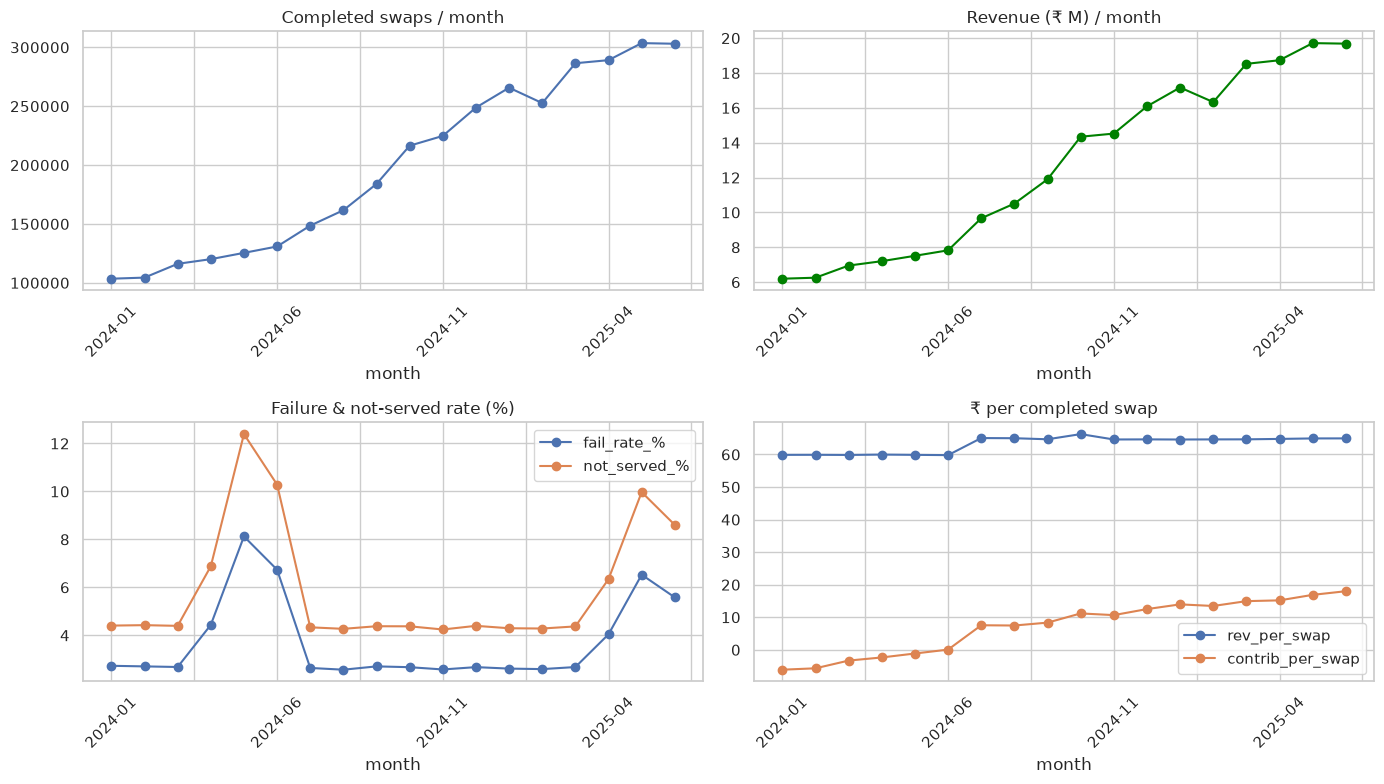

First 3 months vs last 3 months:
                    first_3m      last_3m  change_%
completed          108007.67    298590.67    176.45
revenue           6467905.50  19375706.00    199.57
fail_rate_%             2.71         5.38     99.01
not_served_%            4.41         8.31     88.39
rev_per_swap           59.88        64.89      8.36
contrib_per_swap       -5.03        16.69   -431.74
wait_p90              433.67       442.80      2.11
stations               90.00       149.67     66.30


In [14]:
m = swaps.groupby("month").agg(
    attempts=("completed", "size"), completed=("completed", "sum"), failed=("failed", "sum"),
    abandoned=("abandoned", "sum"), revenue=("revenue", "sum"), contrib=("contrib", "sum"),
    wait_p90=("queue_wait_sec", lambda s: s.quantile(0.9)),
    stations=("station_id", "nunique"))
m["fail_rate_%"]       = m.failed / m.attempts * 100
m["not_served_%"]      = (m.attempts - m.completed) / m.attempts * 100
m["rev_per_swap"]      = m.revenue / m.completed
m["contrib_per_swap"]  = m.contrib / m.completed
m.index = m.index.astype(str)
display(m.round(2))

fig, ax = plt.subplots(2, 2, figsize=(14, 8))
m.completed.plot(ax=ax[0,0], marker="o", title="Completed swaps / month")
(m.revenue/1e6).plot(ax=ax[0,1], marker="o", color="green", title="Revenue (₹ M) / month")
m[["fail_rate_%", "not_served_%"]].plot(ax=ax[1,0], marker="o", title="Failure & not-served rate (%)")
m[["rev_per_swap", "contrib_per_swap"]].plot(ax=ax[1,1], marker="o", title="₹ per completed swap")
for a in ax.flat: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

f, l = m.iloc[:3].mean(numeric_only=True), m.iloc[-3:].mean(numeric_only=True)
print("First 3 months vs last 3 months:")
print(pd.DataFrame({"first_3m": f, "last_3m": l, "change_%": (l/f - 1)*100})
      .loc[["completed", "revenue", "fail_rate_%", "not_served_%", "rev_per_swap", "contrib_per_swap", "wait_p90", "stations"]].round(2))

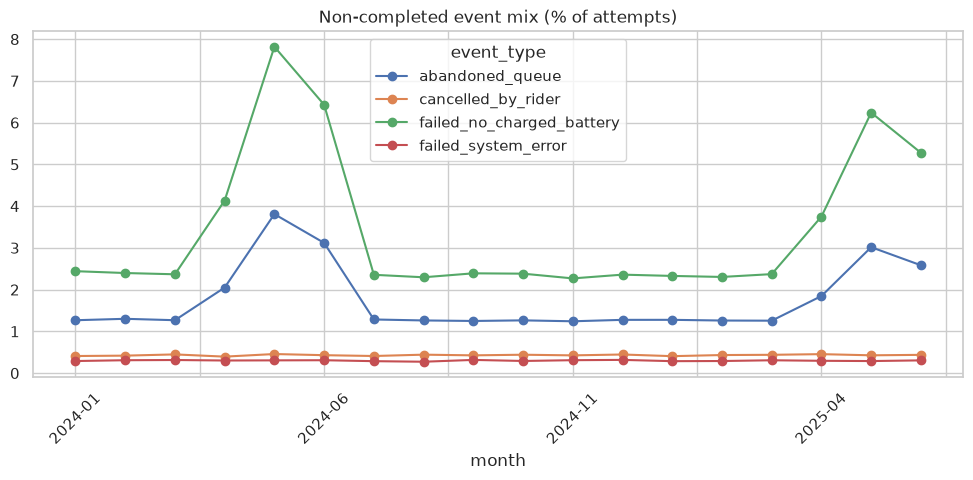

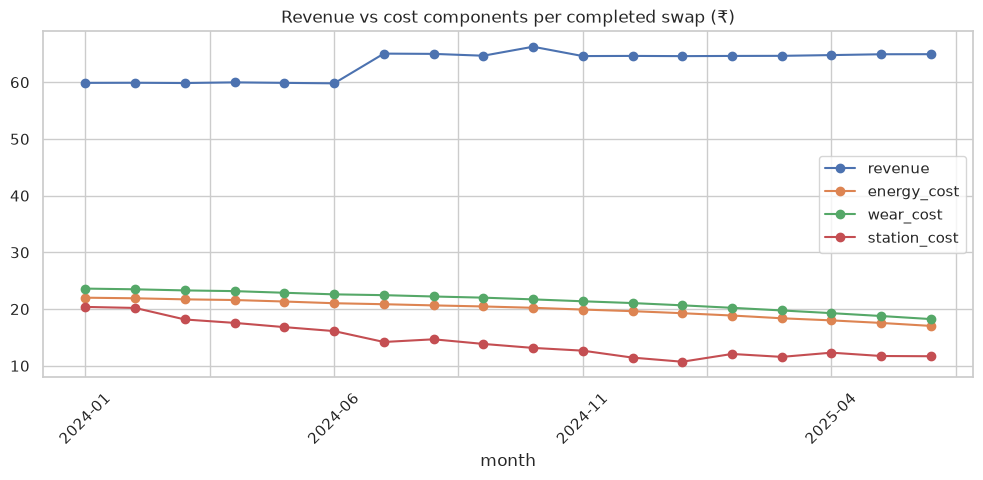

,revenue,energy_cost,wear_cost,station_cost
month,,,,
2024-01,59.889999,22.01,23.61,20.38
2024-02,59.910000,21.90,23.49,20.20
2024-03,59.860001,21.71,23.29,18.16
2024-04,59.980000,21.60,23.16,17.56
2024-05,59.889999,21.33,22.87,16.82
2024-06,59.810001,21.03,22.60,16.12
2024-07,65.050003,20.86,22.45,14.20
2024-08,65.000000,20.65,22.22,14.67
2024-09,64.669998,20.46,22.01,13.85


In [15]:
# Event-type mix over time (which failure type is growing?)
mix = pd.crosstab(swaps.month.astype(str), swaps.event_type, normalize="index") * 100
mix.drop(columns="swap_completed", errors="ignore").plot(marker="o", title="Non-completed event mix (% of attempts)")
plt.xticks(rotation=45); plt.show()

# Cost stack per swap over time (where is margin going?)
cs = swaps[swaps.completed].groupby(swaps.month.astype(str))[["revenue", "energy_cost", "wear_cost", "station_cost"]].mean()
cs.plot(marker="o", title="Revenue vs cost components per completed swap (₹)"); plt.xticks(rotation=45); plt.show()
display(cs.round(2))

### 📝 Q1 findings — growth and quality/profit tell different stories
- **Volume & revenue:** completed swaps **+177%** and revenue **+200%** (first 3 vs last 3 months); stations 90 → 150.
- **Service quality:** not-served rate **4.4% → 8.3%**, failure rate **2.7% → 5.4%**. Failures are strongly **seasonal**: spikes every April–June (8.1% in May 2024, 6.5% in May 2025), almost entirely *failed_no_charged_battery* and *abandoned_queue*.
- **Price:** base price rose in **July 2024** (2W ₹60 → ₹65, 3W ₹100 → ₹110) → revenue per swap +8%.
- **Margin:** with a fixed battery-life assumption (model v1) margin looks like it improves. With wear based on *actual* battery degradation (model v2, Q5), the July price gain is **wiped out from Sep 2024** — see Q4/Q5.
- **So what:** growth metrics hide a quality and unit-economics problem.

---
# Part 2 — Core questions Q2–Q6
The cleaned data is reloaded from `swaps_clean.parquet` with only the columns needed, to keep memory low.

In [16]:
import gc
del swaps, sm
gc.collect()

17164

## 0. Setup

In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os, gc, warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (12, 4.5)
DATA_DIR = globals().get("LOCAL", globals().get("DATA_DIR", "./data"))
KEY = {}   # key numbers collected for the report

cols = ["rider_id", "station_id", "event_ts", "event_type", "queue_wait_sec", "battery_in_id", "battery_out_id",
        "soc_in_pct", "soh_in_pct", "soh_out_pct", "km_since_last_swap", "tariff_code", "list_price_inr",
        "discount_inr", "amount_charged_inr", "energy_to_recharge_kwh", "sync_mode", "city", "location_type",
        "host_type", "charger_generation", "expansion_wave", "connectivity_tier", "partner_id", "vehicle_class",
        "plan_type", "signup_date", "signup_channel", "supplier", "completed", "failed", "abandoned", "not_served",
        "segment", "revenue", "energy_cost", "station_cost", "purchase_cost_inr"]
sw = pd.read_parquet("swaps_clean.parquet", columns=cols)
for c in ["city", "location_type", "host_type", "charger_generation", "expansion_wave", "connectivity_tier",
          "partner_id", "vehicle_class", "plan_type", "signup_channel", "supplier", "segment"]:
    sw[c] = sw[c].astype("category")
sw["month"] = sw.event_ts.dt.to_period("M").astype(str)
sw["date"] = sw.event_ts.dt.normalize()
sw["hour"] = sw.event_ts.dt.hour
sw["stockout"] = sw.event_type.astype(str).eq("failed_no_charged_battery")

def rd(n):
    for fn in [n, n + ".gz"]:
        p = os.path.join(DATA_DIR, fn)
        if os.path.exists(p): return pd.read_csv(p, low_memory=False)
stations = rd("stations.csv"); stations = stations[~stations.station_id.str.startswith("STN-TST")]
riders   = rd("riders.csv");  batt = rd("batteries.csv"); tickets = rd("support_tickets.csv")
cityday  = rd("city_daily_context.csv"); partners = rd("fleet_partners.csv")
cityday["date"] = pd.to_datetime(cityday.date)
tickets["created_ts"] = pd.to_datetime(tickets.created_ts)
riders["signup_date"] = pd.to_datetime(riders.signup_date)
for c in ["manufacture_date", "commission_date", "retired_date"]: batt[c] = pd.to_datetime(batt[c])
for c in ["commissioned_date", "competitor_within_1_5km_since"]: stations[c] = pd.to_datetime(stations[c])
for c in ["contract_start_date", "amendment_date"]: partners[c] = pd.to_datetime(partners[c])
print(sw.shape, f"{sw.memory_usage(deep=True).sum()/1e6:,.0f} MB")

(3813612, 42) 711 MB


## Q2. Service failures & customer experience

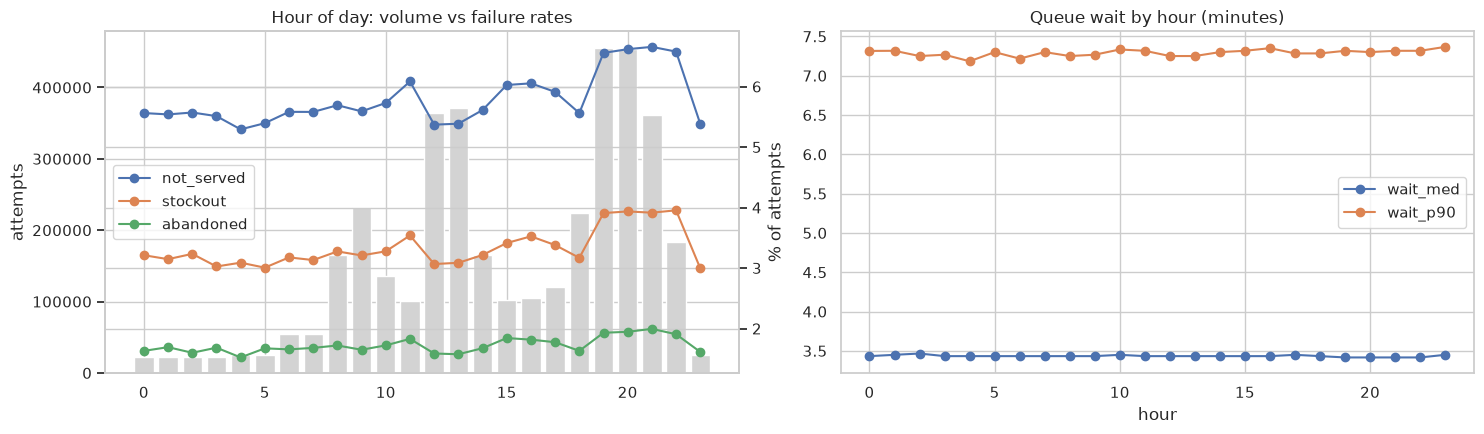

,attempts,not_served,stockout,abandoned,wait_med,wait_p90
hour,,,,,,
0,22382,5.56,3.21,1.63,206.0,438.899994
1,22274,5.54,3.15,1.69,207.0,439.000000
2,22381,5.57,3.23,1.60,208.0,435.000000
3,22207,5.51,3.03,1.68,206.0,436.000000
4,24958,5.29,3.09,1.52,206.0,431.000000
5,24745,5.40,3.01,1.67,206.0,438.000000
6,54653,5.58,3.18,1.66,206.0,433.000000
7,54916,5.58,3.13,1.68,206.0,438.000000
8,164628,5.69,3.28,1.72,206.0,435.000000


In [18]:
h = sw.groupby("hour").agg(attempts=("completed", "size"), not_served=("not_served", "mean"),
                           stockout=("stockout", "mean"), abandoned=("abandoned", "mean"),
                           wait_med=("queue_wait_sec", "median"), wait_p90=("queue_wait_sec", lambda s: s.quantile(.9)))
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].bar(h.index, h.attempts, color="lightgray", label="attempts"); ax[0].set_ylabel("attempts")
a2 = ax[0].twinx(); (h[["not_served", "stockout", "abandoned"]] * 100).plot(ax=a2, marker="o"); a2.set_ylabel("% of attempts")
ax[0].set_title("Hour of day: volume vs failure rates")
(h[["wait_med", "wait_p90"]] / 60).plot(ax=ax[1], marker="o", title="Queue wait by hour (minutes)")
plt.tight_layout(); plt.show()
display((h.assign(**{c: h[c] * 100 for c in ["not_served", "stockout", "abandoned"]})).round(2))

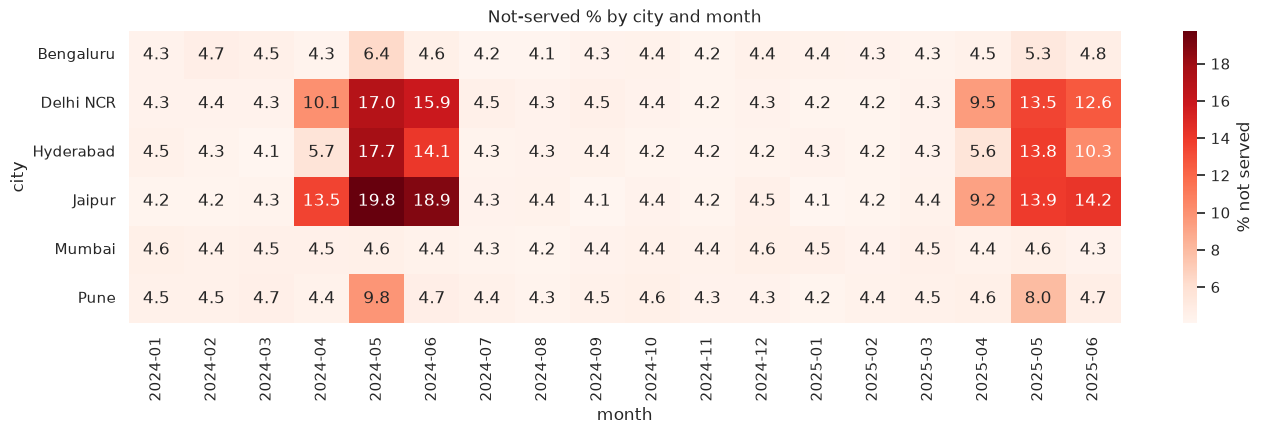

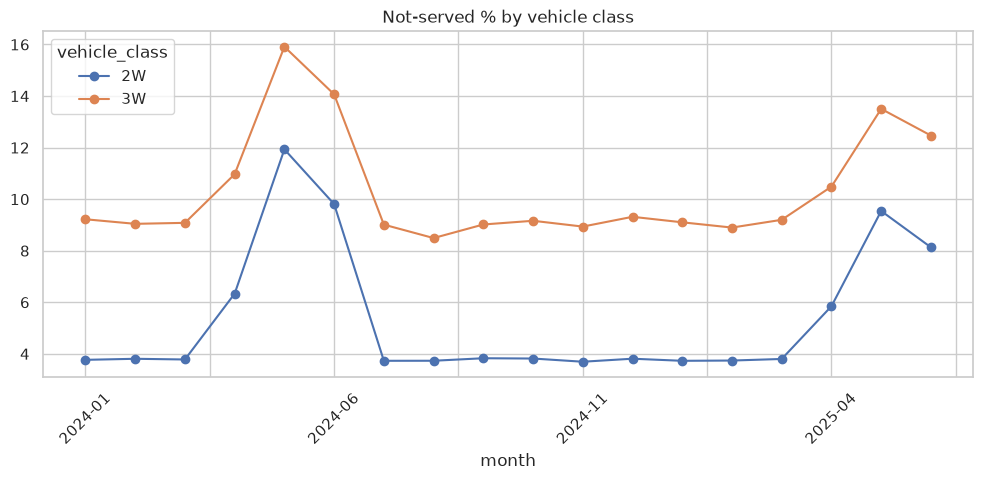

               not_served  stockout  abandoned
vehicle_class                                 
2W                   5.45      3.12       1.60
3W                  10.39      6.42       3.23


In [19]:
# City x month heatmap of not-served %
cm = sw.pivot_table(index="city", columns="month", values="not_served", aggfunc="mean", observed=True) * 100
plt.figure(figsize=(16, 3.8)); sns.heatmap(cm, cmap="Reds", annot=True, fmt=".1f", cbar_kws={"label": "% not served"})
plt.title("Not-served % by city and month"); plt.show()

vc = sw.groupby(["vehicle_class", "month"], observed=True).not_served.mean().unstack(0) * 100
vc.plot(marker="o", title="Not-served % by vehicle class"); plt.xticks(rotation=45); plt.show()
print((sw.groupby("vehicle_class", observed=True)[["not_served", "stockout", "abandoned"]].mean() * 100).round(2))

,attempts,not_served,stockout,wait_p90
temp_band,,,,
<25,2095767,4.34,2.34,433.0
25-30,435260,4.38,2.39,433.0
30-35,507908,4.43,2.41,433.0
35-38,321862,9.10,5.61,444.0
38-41,207468,14.43,9.37,460.0
41+,245347,14.93,9.58,465.0


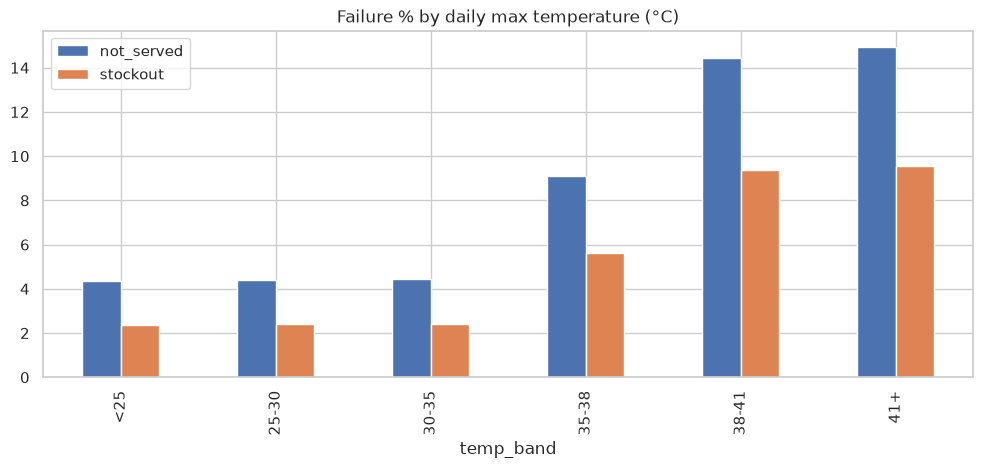

Not-served % on heat-alert days vs normal: {False: 5.52, True: 14.94}


In [20]:
# Heat: join daily city weather
sw = sw.merge(cityday[["city", "date", "max_temp_c", "heat_alert", "rainfall_mm", "competitor_promo_active"]],
              on=["city", "date"], how="left")
sw["temp_band"] = pd.cut(sw.max_temp_c, [-50, 25, 30, 35, 38, 41, 60], labels=["<25", "25-30", "30-35", "35-38", "38-41", "41+"])
t = sw.groupby("temp_band", observed=True).agg(attempts=("completed", "size"), not_served=("not_served", "mean"),
                                               stockout=("stockout", "mean"), wait_p90=("queue_wait_sec", lambda s: s.quantile(.9)))
t[["not_served", "stockout"]] *= 100
display(t.round(2))
t[["not_served", "stockout"]].plot.bar(title="Failure % by daily max temperature (°C)"); plt.show()
hot = sw.groupby("heat_alert").not_served.mean() * 100
KEY["not_served_heat_alert_vs_not"] = hot.round(2).to_dict()
print("Not-served % on heat-alert days vs normal:", hot.round(2).to_dict())

Top 10% of stations (15) = 24.1% of all not-served attempts but only 17.2% of attempts


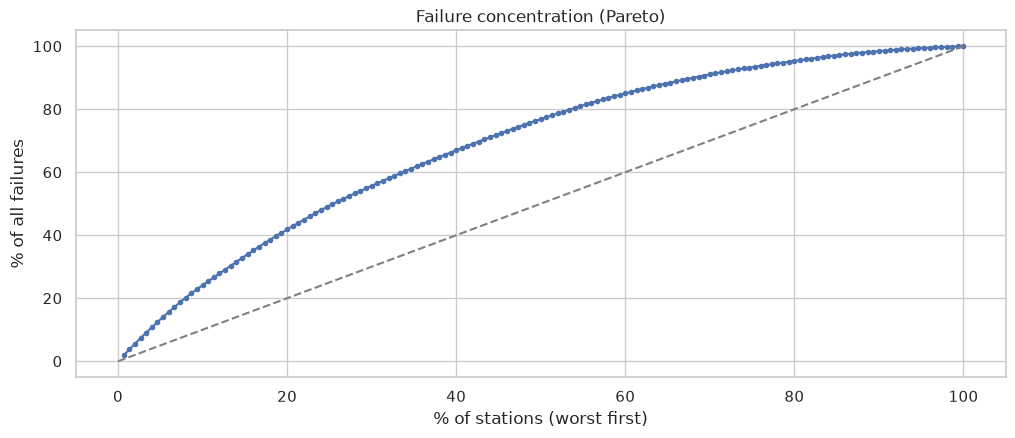

,attempts,not_served_n,not_served_%,cum_share_%,station_id,city,zone,location_type,charger_generation,expansion_wave,connectivity_tier,slots_2w,inventory_target_2w
42,49535,4270,8.62,1.87,STN-DEL-043,Delhi NCR,DEL-East,commercial_hub,Gen1,Launch,poor,12,32
137,48888,4242,8.68,3.73,STN-JAI-138,Jaipur,JAI-Malviya Nagar,market,Gen1,Launch,poor,12,31
71,51765,4176,8.07,5.56,STN-HYD-072,Hyderabad,HYD-Hitech City,commercial_hub,Gen1,Launch,good,12,19
49,47000,4053,8.62,7.33,STN-DEL-050,Delhi NCR,DEL-East,commercial_hub,Gen1,Launch,poor,12,29
140,45594,3981,8.73,9.08,STN-JAI-141,Jaipur,JAI-Malviya Nagar,commercial_hub,Gen1,Launch,good,16,40
136,44318,3881,8.76,10.78,STN-JAI-137,Jaipur,JAI-Malviya Nagar,commercial_hub,Gen1,Launch,fair,8,19
69,49688,3768,7.58,12.43,STN-HYD-070,Hyderabad,HYD-South,market,Gen1,Launch,good,16,11
139,44063,3733,8.47,14.06,STN-JAI-140,Jaipur,JAI-Malviya Nagar,commercial_hub,Gen1,Launch,fair,16,45
133,42925,3612,8.41,15.64,STN-JAI-134,Jaipur,JAI-Malviya Nagar,commercial_hub,Gen1,Launch,good,16,37
46,41594,3509,8.44,17.18,STN-DEL-047,Delhi NCR,DEL-South,market,Gen1,Launch,good,12,15


In [21]:
# Concentration: are failures spread evenly across stations?
s = sw.groupby("station_id", observed=True).agg(attempts=("completed", "size"), not_served_n=("not_served", "sum"))
s["not_served_%"] = s.not_served_n / s.attempts * 100
s = s.sort_values("not_served_n", ascending=False)
s["cum_share_%"] = s.not_served_n.cumsum() / s.not_served_n.sum() * 100
top10 = int(np.ceil(len(s) * .10)); top20 = int(np.ceil(len(s) * .20))
KEY["share_failures_top10pct_stations"] = round(s["cum_share_%"].iloc[top10 - 1], 1)
KEY["share_attempts_top10pct_stations"] = round(s.attempts.iloc[:top10].sum() / s.attempts.sum() * 100, 1)
print(f"Top 10% of stations ({top10}) = {KEY['share_failures_top10pct_stations']}% of all not-served attempts "
      f"but only {KEY['share_attempts_top10pct_stations']}% of attempts")
plt.plot(np.arange(1, len(s) + 1) / len(s) * 100, s["cum_share_%"].to_numpy(), marker=".")
plt.plot([0, 100], [0, 100], "--", color="gray"); plt.xlabel("% of stations (worst first)"); plt.ylabel("% of all failures")
plt.title("Failure concentration (Pareto)"); plt.show()
worst = s.head(15).merge(stations[["station_id", "city", "zone", "location_type", "charger_generation", "expansion_wave",
                                   "connectivity_tier", "slots_2w", "inventory_target_2w"]], left_index=True, right_on="station_id")
display(worst.round(2))

In [22]:
# Mechanism: link failures to hourly station telemetry (stock, cabinet heat, quarantined packs, outages)
hourly = rd("station_hourly_status.csv")
hourly = hourly[~hourly.station_id.str.startswith("STN-TST")]
hourly["hour_start"] = pd.to_datetime(hourly.hour_start)
sw["hour_start"] = sw.event_ts.dt.floor("h")
ev = sw.groupby(["station_id", "hour_start"], observed=True).agg(att=("completed", "size"), ns=("not_served", "sum"),
                                                                  so=("stockout", "sum")).reset_index()
ev["station_id"] = ev.station_id.astype(str)
hh = hourly.merge(ev, on=["station_id", "hour_start"], how="left").fillna({"att": 0, "ns": 0, "so": 0})
hh = hh.merge(stations[["station_id", "charger_generation", "city", "expansion_wave", "location_type", "connectivity_tier"]], on="station_id")
ok = hh[hh.telemetry_status == "ok"]
def rate(g): return pd.Series({"attempts": g.att.sum(), "not_served_%": g.ns.sum() / max(g.att.sum(), 1) * 100,
                               "stockout_%": g.so.sum() / max(g.att.sum(), 1) * 100, "avg_charge_min": g.avg_charge_minutes.mean()})
ok["cab_band"] = pd.cut(ok.cabinet_temp_c, [-10, 30, 35, 40, 45, 50, 80])
print("By cabinet temperature (°C):"); display(ok.groupby("cab_band", observed=True).apply(rate).round(2))
ok["stock_zero"] = ok.charged_2w_min.eq(0)
print("Hours with zero charged 2W packs vs not:"); display(ok.groupby("stock_zero").apply(rate).round(2))
ok["quar"] = ok.packs_quarantined.fillna(0).gt(0)
print("Hours with quarantined packs vs not:"); display(ok.groupby("quar").apply(rate).round(2))
ok["outage"] = ok.outage_minutes.gt(0)
print("Hours with power outage vs not:"); display(ok.groupby("outage").apply(rate).round(2))

By cabinet temperature (°C):


,attempts,not_served_%,stockout_%,avg_charge_min
cab_band,,,,
"(-10, 30]",2365539.0,4.95,2.77,73.53
"(30, 35]",484590.0,5.04,2.83,72.37
"(35, 40]",379157.0,7.01,4.21,69.77
"(40, 45]",286042.0,10.52,6.62,79.41
"(45, 50]",128251.0,13.12,8.33,107.30
"(50, 80]",48229.0,11.91,7.46,142.61


Hours with zero charged 2W packs vs not:


,attempts,not_served_%,stockout_%,avg_charge_min
stock_zero,,,,
False,3635785.0,5.89,3.42,74.10
True,56023.0,11.61,7.26,143.14


Hours with quarantined packs vs not:


,attempts,not_served_%,stockout_%,avg_charge_min
quar,,,,
False,3686744.0,5.97,3.47,74.96
True,5064.0,10.90,6.79,95.72


Hours with power outage vs not:


,attempts,not_served_%,stockout_%,avg_charge_min
outage,,,,
False,3691080.0,5.98,3.48,74.98
True,728.0,6.59,3.57,72.48


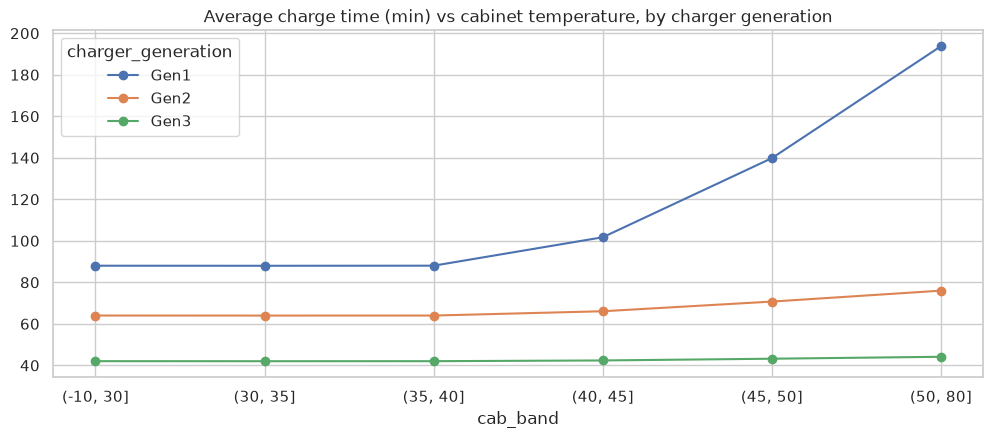

charger_generation,Gen1,Gen2,Gen3
cab_band,,,
"(-10, 30]",88.0,64.0,42.0
"(30, 35]",88.0,64.0,42.0
"(35, 40]",88.0,64.0,42.0
"(40, 45]",101.7,66.1,42.4
"(45, 50]",139.8,70.7,43.2
"(50, 80]",193.7,76.0,44.1


In [23]:
cg = ok.groupby(["cab_band", "charger_generation"], observed=True).avg_charge_minutes.mean().unstack()
cg.plot(marker="o", title="Average charge time (min) vs cabinet temperature, by charger generation"); plt.show()
display(cg.round(1))

### 📝 Q2 findings — failures are driven by heat, concentrated at old stations
- **Weather is the strongest signal:** not-served rate is **~4.4%** below 35°C but **14.4–14.9%** above 38°C; **14.9%** on heat-alert days vs **5.5%** otherwise.
- **Mechanism (telemetry):** hot cabinets slow charging on **Gen1** chargers (88 → 140 → 194 min at 45–50°C / 50°C+) while Gen3 stays at ~42 min → fewer charged packs → stock-outs. Hours with zero charged 2W packs have **11.6%** not-served vs 5.9%.
- **Where:** the top 10% of stations carry **24.1%** of failures on 17.2% of attempts; **all 15 worst stations are Gen1 Launch stations** in Jaipur, Delhi NCR and Hyderabad.
- **Who / when:** **3W** riders fail twice as often (10.4% vs 5.5%). Evening peak (19–22h) is the worst window (~6.6%). Median wait is flat (~3.5 min), so the problem is *no battery*, not queues.
- Power outages and quarantined packs are rare and minor contributors.

## Q3. Station & geographic patterns

In [24]:
tk_st = tickets.dropna(subset=["station_id"]).groupby("station_id").size().rename("tickets")
st_att = sw.groupby("station_id", observed=True).agg(attempts=("completed", "size"), ns=("not_served", "sum"),
                                                     wait_p90=("queue_wait_sec", lambda s: s.quantile(.9)))
st_att.index = st_att.index.astype(str)
ch = ok.groupby("station_id").avg_charge_minutes.mean().rename("avg_charge_min")
S = stations.set_index("station_id").join(st_att).join(tk_st).join(ch)
S["tickets"] = S.tickets.fillna(0)
def seg(col):
    g = S.groupby(col).agg(stations=("attempts", "size"), attempts=("attempts", "sum"), ns=("ns", "sum"),
                           tickets=("tickets", "sum"), wait_p90=("wait_p90", "median"), avg_charge_min=("avg_charge_min", "mean"))
    g["not_served_%"] = g.ns / g.attempts * 100
    g["tickets_per_1k_attempts"] = g.tickets / g.attempts * 1000
    return g.drop(columns=["ns", "tickets"]).round(2).sort_values("not_served_%", ascending=False)
for col in ["charger_generation", "location_type", "expansion_wave", "connectivity_tier", "host_type", "city"]:
    print(f"==== {col}"); display(seg(col))

==== charger_generation


,stations,attempts,wait_p90,avg_charge_min,not_served_%,tickets_per_1k_attempts
charger_generation,,,,,,
Gen1,51,1821360,442.0,91.81,7.23,11.77
Gen2,62,1620143,434.0,64.25,4.85,9.45
Gen3,37,372109,433.0,42.15,4.84,12.07


==== location_type


,stations,attempts,wait_p90,avg_charge_min,not_served_%,tickets_per_1k_attempts
location_type,,,,,,
market,47,1246521,435.0,68.36,6.24,10.79
commercial_hub,44,1535122,437.0,76.63,6.18,10.76
transit_hub,10,172646,436.5,63.54,5.97,10.55
residential,21,382160,434.0,62.03,5.45,10.80
tech_park,7,147490,436.0,72.19,5.21,9.55
highway_fuel_pump,21,329673,434.0,57.02,5.11,11.90


==== expansion_wave


...

,stations,attempts,wait_p90,avg_charge_min,not_served_%,tickets_per_1k_attempts
connectivity_tier,,,,,,
fair,29,668974,436.200012,69.44,6.31,11.54
poor,23,641199,436.899994,68.23,6.27,10.92
good,98,2503439,435.000000,67.78,5.83,10.59


==== host_type


,stations,attempts,wait_p90,avg_charge_min,not_served_%,tickets_per_1k_attempts
host_type,,,,,,
kirana,38,944750,435.000000,65.92,6.08,10.76
mall_parking,44,1108313,436.000000,68.20,6.00,10.86
owned_lot,37,964840,436.100006,69.10,5.94,10.77
fuel_retailer,31,795709,435.000000,69.79,5.91,10.86


==== city


,stations,attempts,wait_p90,avg_charge_min,not_served_%,tickets_per_1k_attempts
city,,,,,,
Jaipur,18,487372,444.000000,75.20,7.85,13.41
Delhi NCR,30,768554,439.500000,72.18,7.35,12.89
Hyderabad,26,711681,436.600006,71.83,6.69,12.08
Pune,22,552771,434.000000,62.64,4.99,9.10
Bengaluru,32,763145,433.000000,66.08,4.55,8.72
Mumbai,22,530089,433.000000,61.21,4.45,8.52


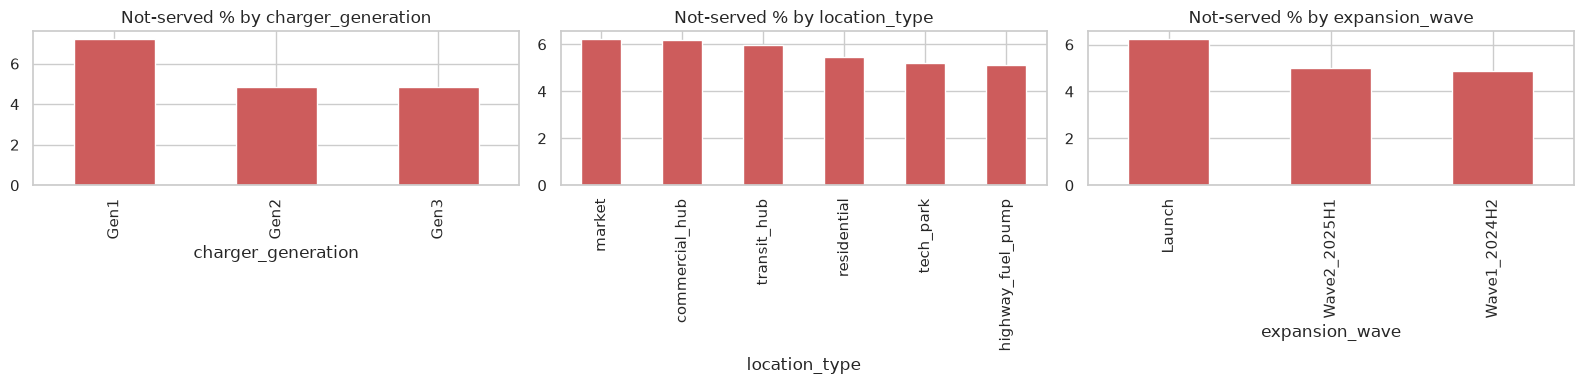

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, col in zip(ax, ["charger_generation", "location_type", "expansion_wave"]):
    seg(col)["not_served_%"].plot.bar(ax=a, title=f"Not-served % by {col}", color="indianred")
plt.tight_layout(); plt.show()

,att_per_slot_day,not_served_%,wait_p90
load_band,,,
Q1 low,2.61,5.46,436.679993
Q2,3.69,6.06,437.660004
Q3,4.85,5.52,435.619995
Q4 high,8.46,5.61,436.179993


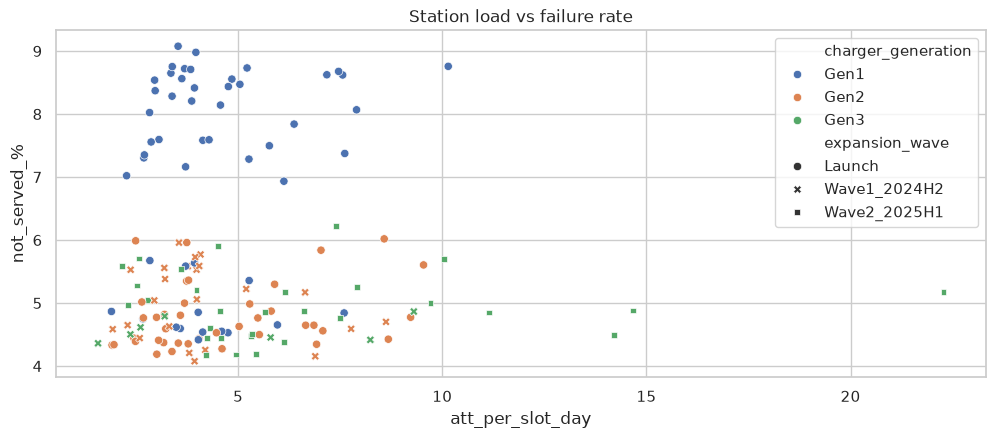

In [26]:
# Load vs capacity: attempts per 2W slot per day and its link to failures
days = (pd.Timestamp("2025-06-30") - S.commissioned_date.clip(lower=pd.Timestamp("2024-01-01"))).dt.days.clip(lower=1)
S["att_per_slot_day"] = S.attempts / (S.slots_2w + S.slots_3w).replace(0, np.nan) / days
S["not_served_%"] = S.ns / S.attempts * 100
S["load_band"] = pd.qcut(S.att_per_slot_day, 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
display(S.groupby("load_band", observed=True)[["att_per_slot_day", "not_served_%", "wait_p90"]].mean().round(2))
sns.scatterplot(data=S, x="att_per_slot_day", y="not_served_%", hue="charger_generation", style="expansion_wave")
plt.title("Station load vs failure rate"); plt.show()

In [27]:
# Expansion waves: did new stations open where the existing ones were overloaded?
zone_pre = sw[(sw.expansion_wave.astype(str) == "Launch") & (sw.event_ts < "2024-07-01")] \
    .merge(stations[["station_id", "zone"]].astype({"station_id": "category"}), on="station_id") \
    .groupby("zone").not_served.mean().mul(100).rename("launch_zone_not_served_%_H1_2024")
new_st = stations[stations.expansion_wave != "Launch"].groupby("zone").size().rename("new_stations")
zz = pd.concat([zone_pre, new_st], axis=1).fillna({"new_stations": 0})
zz["got_new_station"] = zz.new_stations > 0
display(zz.groupby("got_new_station")["launch_zone_not_served_%_H1_2024"].describe().round(2))
print("Top 10 most-stressed zones before expansion and how many new stations they got:")
display(zz.sort_values("launch_zone_not_served_%_H1_2024", ascending=False).head(10).round(2))
display(S[S.expansion_wave != "Launch"].groupby(["expansion_wave", "location_type"]).size().unstack(fill_value=0))

,count,mean,std,min,25%,50%,75%,max
got_new_station,,,,,,,,
False,1.0,4.48,NaN,4.48,4.48,4.48,4.48,4.48
True,24.0,7.41,2.64,4.42,4.82,7.16,9.49,11.69


Top 10 most-stressed zones before expansion and how many new stations they got:


,launch_zone_not_served_%_H1_2024,new_stations,got_new_station
zone,,,
JAI-Malviya Nagar,11.69,4.0,True
JAI-Vaishali,11.53,3.0,True
DEL-South,11.08,1.0,True
DEL-West,10.16,4.0,True
DEL-East,10.14,3.0,True
HYD-West,9.53,2.0,True
DEL-Noida,9.47,1.0,True
HYD-South,9.36,1.0,True
DEL-Gurugram-Cyber,9.25,2.0,True


location_type,commercial_hub,highway_fuel_pump,market,residential,tech_park,transit_hub
expansion_wave,,,,,,
Wave1_2024H2,1,14,0,13,1,1
Wave2_2025H1,4,5,14,2,1,4


### 📝 Q3 findings — equipment generation and climate matter; site type and load do not
- **Charger generation:** Gen1 **7.2%** not-served vs **4.8%** for Gen2/Gen3; average charge time 92 vs 64 vs 42 min.
- **Geography:** hot cities fail most — Jaipur 7.9%, Delhi NCR 7.4%, Hyderabad 6.7% vs Mumbai 4.5%, Bengaluru 4.6%, Pune 5.0%. Tickets per 1k attempts follow the same order (13.4 vs 8.5).
- **Not drivers:** location type, host type and connectivity differ by < 1 pp. Station load (attempts per slot per day) shows **no** relationship with failure rate → this is a **charging-speed** problem, not a capacity problem.
- **Expansion waves:** new stations have fewer failures, but Wave 1 went mostly to **highway fuel pumps and residential sites** (27 of 30), i.e. easy-to-open, lower-demand locations. The stressed Gen1 launch stations were **not upgraded**, so the summer 2025 spike repeated.

## Q4. Battery & equipment performance

packs  current_soh  loss_per_month  loss_per_100_swaps  retired first_commissioned
pack_type supplier                                                                                    
2W_2.1kWh Amptek     1098       79.957           4.065               2.994        0         2024-03-01
          Cellora    3035       79.971           2.350               2.987        0         2023-03-01
          Kyron      1385       60.532           5.024               9.639     1385         2024-09-10
3W_4.8kWh Amptek      209       86.514           2.813               3.351        0         2024-03-01
          Cellora     520       86.522           1.753               3.350        0         2023-03-01
          Kyron       253       81.348           3.853               3.493       53         2024-07-01

Lots ranked by degradation speed (z > 2 = anomaly):


packs  loss_per_month  loss_per_100_swaps  current_soh  retired      z
supplier manufacturing_lot                                                                        
Amptek   AM-2506               47          18.100               3.080       81.179        0  4.085
         AM-2505               79          13.005               3.005       81.152        0  2.672
Kyron    KY-2418               14          12.614               3.480       86.500        0  2.564
Cellora  CE-2505              134          12.491               3.046       81.363        0  2.529
Kyron    KY-2417               20           9.202               3.250       86.610        0  1.617
Cellora  CE-2504              135           7.422               3.059       80.924        0  1.124
Amptek   AM-2504               84           7.350               3.052       80.888        0  1.104
         AM-2503               89           5.232               3.046       80.931        0  0.516
Cellora  CE-2503              150           5.177               3.016       81.189        0  0.501
Kyron    KY-2409              481           4.952               9.616       60.915      473  0.438
         KY-2408              500           4.921               9.599       61.048      489  0.430
         KY-2407              480           4.876               9.574       60.986      476  0.417

Retirement reasons: {'end_of_life': 1438}


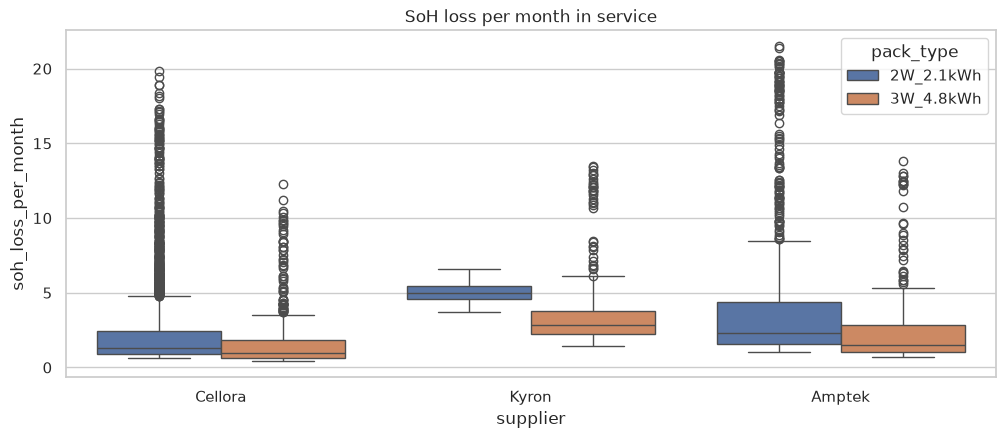

In [28]:
B = batt.copy()
end = B.retired_date.fillna(pd.Timestamp("2025-06-30"))
B["months_in_service"] = ((end - B.commission_date).dt.days / 30.44).clip(lower=1)
B["soh_lost"] = B.initial_soh_pct - B.current_soh_pct
B["soh_loss_per_month"] = B.soh_lost / B.months_in_service
issued = sw.loc[sw.completed, "battery_out_id"].astype(str).value_counts().rename("swaps_issued")
B = B.merge(issued, left_on="battery_id", right_index=True, how="left").fillna({"swaps_issued": 0})
B["soh_loss_per_100_swaps"] = B.soh_lost / B.swaps_issued.replace(0, np.nan) * 100
g = B.groupby(["pack_type", "supplier"]).agg(packs=("battery_id", "size"), current_soh=("current_soh_pct", "mean"),
      loss_per_month=("soh_loss_per_month", "mean"), loss_per_100_swaps=("soh_loss_per_100_swaps", "median"),
      retired=("retired_date", lambda s: s.notna().sum()), first_commissioned=("commission_date", "min"))
display(g.round(3))
lot = B.groupby(["supplier", "manufacturing_lot"]).agg(packs=("battery_id", "size"), loss_per_month=("soh_loss_per_month", "mean"),
      loss_per_100_swaps=("soh_loss_per_100_swaps", "median"), current_soh=("current_soh_pct", "mean"),
      retired=("retired_date", lambda s: s.notna().sum()))
lot["z"] = (lot.loss_per_month - lot.loss_per_month.mean()) / lot.loss_per_month.std()
print("Lots ranked by degradation speed (z > 2 = anomaly):"); display(lot.sort_values("loss_per_month", ascending=False).head(12).round(3))
print("Retirement reasons:", B.retirement_reason.value_counts().to_dict())
sns.boxplot(data=B, x="supplier", y="soh_loss_per_month", hue="pack_type"); plt.title("SoH loss per month in service"); plt.show()

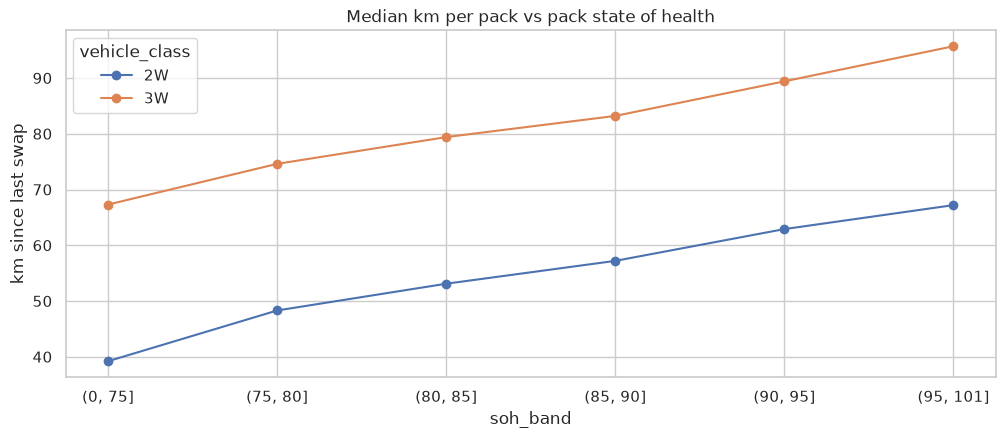

vehicle_class,2W,3W
soh_band,,
"(0, 75]",39.200001,67.300003
"(75, 80]",48.299999,74.599998
"(80, 85]",53.099998,79.400002
"(85, 90]",57.200001,83.199997
"(90, 95]",62.900002,89.400002
"(95, 101]",67.199997,95.699997


median_km  mean_soh_in  deep_discharge_pct
vehicle_class supplier_in                                            
2W            Amptek       60.599998    89.709999           55.419998
              Cellora      60.599998    89.709999           55.310001
              Kyron        48.000000    80.339996           55.590000
3W            Amptek       89.800003    92.980003           54.200001
              Cellora      89.699997    92.980003           54.619999
              Kyron        87.599998    90.419998           54.360001

In [29]:
# Delivered range: km covered on returned pack vs its state of health
r = sw[sw.km_since_last_swap.notna() & sw.soh_in_pct.notna()].copy()
r["soh_band"] = pd.cut(r.soh_in_pct, [0, 75, 80, 85, 90, 95, 101])
bid = r.battery_in_id.astype(str)
r["supplier_in"] = bid.map(B.set_index("battery_id").supplier)
rng = r.groupby(["vehicle_class", "soh_band"], observed=True).km_since_last_swap.median().unstack(0)
rng.plot(marker="o", title="Median km per pack vs pack state of health"); plt.ylabel("km since last swap"); plt.show()
display(rng.round(1))
display(r.groupby(["vehicle_class", "supplier_in"], observed=True).agg(median_km=("km_since_last_swap", "median"),
        mean_soh_in=("soh_in_pct", "mean"), deep_discharge_pct=("soc_in_pct", lambda s: (s < 10).mean() * 100)).round(2))

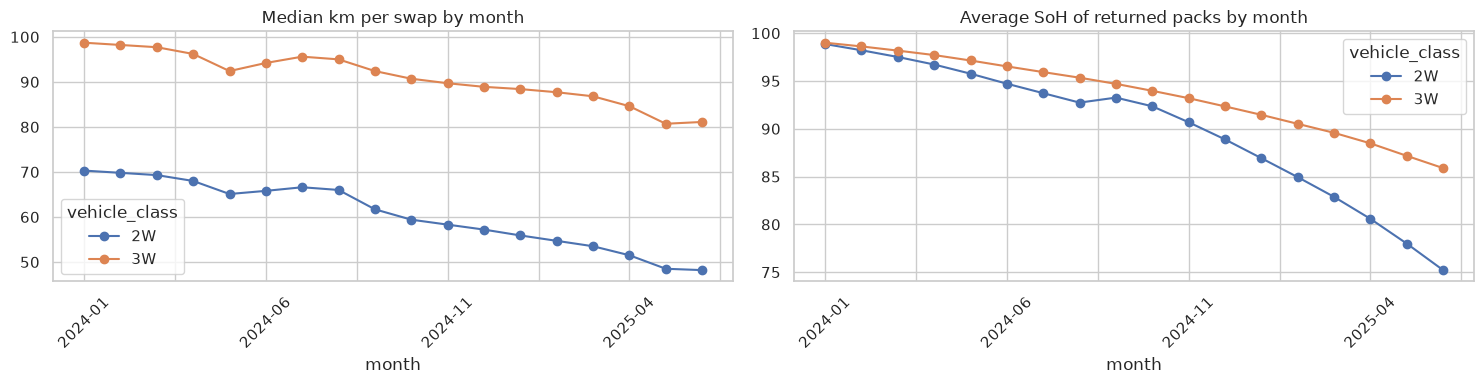

supplier
Amptek     455.9
Cellora    454.7
Kyron      527.7
Name: battery_tickets_per_100_packs, dtype: float64

36356

In [30]:
# Swap frequency: riders who get low-SoH packs must swap more often (km per swap falls)
mth = r.groupby(["month", "vehicle_class"], observed=True).agg(km=("km_since_last_swap", "median"), soh=("soh_in_pct", "mean")).unstack()
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
mth["km"].plot(ax=ax[0], marker="o", title="Median km per swap by month"); mth["soh"].plot(ax=ax[1], marker="o", title="Average SoH of returned packs by month")
for a in ax: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
KEY["km_per_swap_first_last_month"] = r.groupby("month").km_since_last_swap.median().iloc[[0, -1]].round(1).to_dict()
# Battery-linked tickets per 100 packs, by supplier
tb = tickets.dropna(subset=["battery_id"]).merge(B[["battery_id", "supplier"]], on="battery_id")
display((tb.groupby("supplier").size() / B.groupby("supplier").size() * 100).rename("battery_tickets_per_100_packs").round(1))
del r; gc.collect()

### 📝 Q4 findings — one supplier cohort stands out: Kyron 2W packs
- **Kyron 2W** (first commissioned Sep 2024) lose **9.6 SoH points per 100 swaps vs ~3.0** for Cellora and Amptek (**3.2× faster**); average SoH **60.5%** and **all 1,385 packs already retired** (end of life).
- **Range:** median km per pack falls from **67 km (SoH 95%+) to 39 km (SoH < 75%)** for 2W; Kyron packs deliver **48 km vs 61 km** → riders must swap more often. Network median km per swap fell **71.7 → 49.9**.
- Kyron packs also generate more battery tickets (**528 vs ~455 per 100 packs**).
- Lots AM-2506 / AM-2505 / CE-2505 show high *monthly* loss only because they are new (short time in service); their loss per swap is normal (~3.0) → **not** real anomalies. Kyron 3W packs are only slightly worse than peers.

## Q5. Pricing & partner economics

**Margin model v2 (used from here):** battery wear is based on *actual* degradation, not a fixed cycle count.
Wear per swap for a pack = purchase cost × (SoH lost ÷ swaps issued) ÷ (initial SoH − 70), i.e. the share of the pack's usable life (down to 70% SoH, assumed end-of-service) consumed by one swap.

,list_price,discount,revenue,energy,wear,station,contrib,promo_free_pct,fleet_share_pct
month,,,,,,,,,
2024-01,64.449997,4.57,59.889999,22.01,38.57,20.38,-21.07,0.0,67.17
2024-02,64.489998,4.58,59.910000,21.90,38.59,20.20,-20.78,0.0,67.15
2024-03,64.410004,4.55,59.860001,21.71,38.47,18.16,-18.49,0.0,66.73
2024-04,64.500000,4.52,59.980000,21.60,38.59,17.56,-17.77,0.0,66.18
2024-05,64.389999,4.51,59.889999,21.33,38.48,16.82,-16.74,0.0,66.04
2024-06,64.290001,4.48,59.810001,21.03,38.35,16.12,-15.69,0.0,65.77
2024-07,69.900002,4.86,65.050003,20.86,38.39,14.20,-8.40,0.0,65.43
2024-08,69.879997,4.88,65.000000,20.65,38.39,14.67,-8.71,0.0,65.63
2024-09,69.550003,4.87,64.669998,20.46,49.86,13.85,-19.49,0.0,65.73


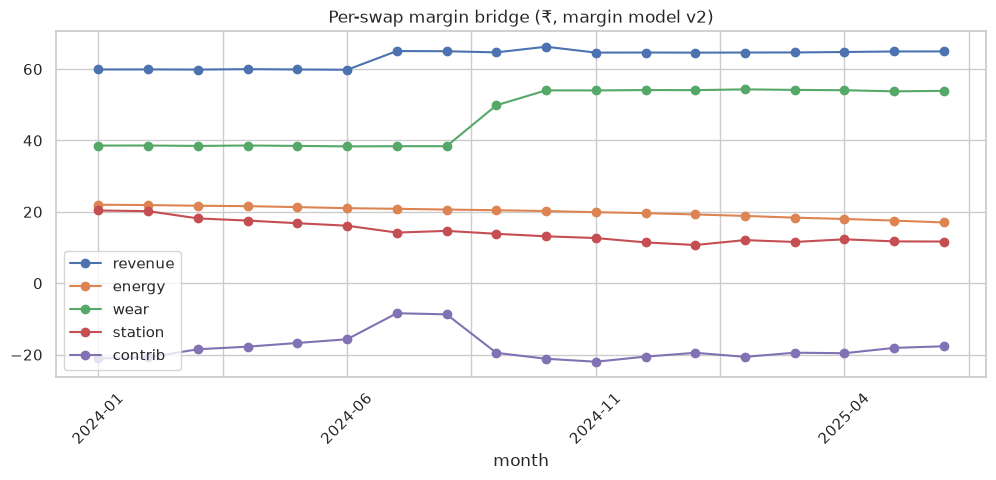

In [31]:
EOL = 70
B["wear_per_swap_v2"] = B.purchase_cost_inr * (B.soh_lost / B.swaps_issued.replace(0, np.nan)) / (B.initial_soh_pct - EOL)
cap = B.wear_per_swap_v2.quantile(.99); B["wear_per_swap_v2"] = B.wear_per_swap_v2.clip(upper=cap)
sw["wear_v2"] = np.where(sw.completed, sw.battery_out_id.astype(str).map(B.set_index("battery_id").wear_per_swap_v2), 0.0)
sw["wear_v2"] = sw.wear_v2.fillna(B.wear_per_swap_v2.median()).where(sw.completed, 0.0)
sw["contrib_v2"] = sw.revenue - sw.energy_cost - sw.wear_v2 - sw.station_cost
c = sw[sw.completed]
bridge = c.groupby("month").agg(list_price=("list_price_inr", "mean"), discount=("discount_inr", "mean"), revenue=("revenue", "mean"),
                                energy=("energy_cost", "mean"), wear=("wear_v2", "mean"), station=("station_cost", "mean"),
                                contrib=("contrib_v2", "mean"), promo_free_pct=("tariff_code", lambda s: (s.astype(str) == "PROMO_FREE").mean() * 100),
                                fleet_share_pct=("segment", lambda s: (s.astype(str) == "Fleet").mean() * 100))
display(bridge.round(2))
bridge[["revenue", "energy", "wear", "station", "contrib"]].plot(marker="o", title="Per-swap margin bridge (₹, margin model v2)")
plt.xticks(rotation=45); plt.show()
KEY["contrib_v2_first3_last3"] = [round(bridge.contrib.iloc[:3].mean(), 2), round(bridge.contrib.iloc[-3:].mean(), 2)]

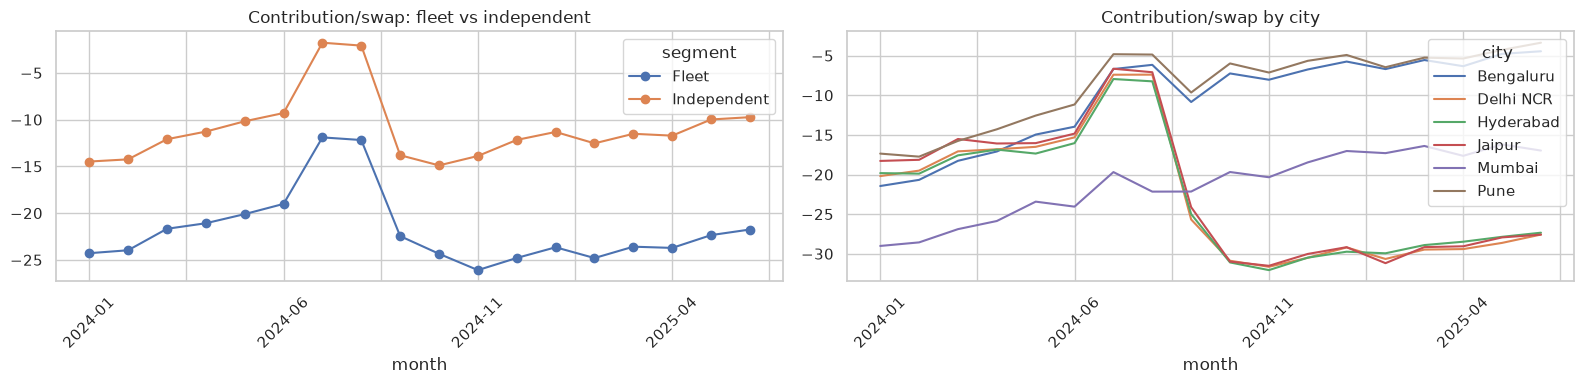

Tariff mix (% of completed swaps) by month:


tariff_code,OFFPEAK,PARTNER,PEAK,STD
month,,,,
2024-01,0.0,67.2,0.0,32.8
2024-02,0.0,67.1,0.0,32.9
2024-03,0.0,66.7,0.0,33.3
2024-04,0.0,66.2,0.0,33.8
2024-05,0.0,66.0,0.0,34.0
2024-06,0.0,65.8,0.0,34.2
2024-07,0.0,65.4,0.0,34.6
2024-08,0.0,65.6,0.0,34.4
2024-09,0.0,65.7,0.0,34.3


In [32]:
# Contribution per swap by segment and by city over time
seg_m = c.groupby(["month", "segment"], observed=True).contrib_v2.mean().unstack()
city_m = c.groupby(["month", "city"], observed=True).contrib_v2.mean().unstack()
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
seg_m.plot(ax=ax[0], marker="o", title="Contribution/swap: fleet vs independent"); city_m.plot(ax=ax[1], title="Contribution/swap by city")
for a in ax: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
print("Tariff mix (% of completed swaps) by month:")
display((pd.crosstab(c.month, c.tariff_code.astype(str), normalize="index") * 100).round(1))

vehicle_class,2W,3W
month,,
2024-01,60.0,100.0
2024-02,60.0,100.0
2024-03,60.0,100.0
2024-04,60.0,100.0
2024-05,60.0,100.0
2024-06,60.0,100.0
2024-07,65.0,110.0
2024-08,65.0,110.0
2024-09,65.0,110.0


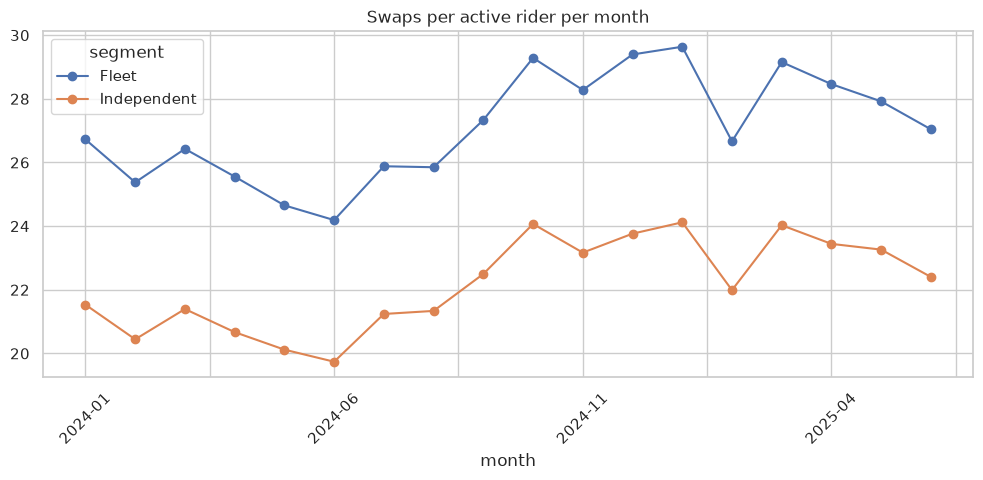

In [33]:
# Base price change: when, how much, and did usage per rider change (independents vs fleet)?
lp = c.groupby(["month", "vehicle_class"], observed=True).list_price_inr.median().unstack()
display(lp)
act = sw[sw.completed].groupby(["month", "segment"], observed=True).agg(swaps=("rider_id", "size"), riders=("rider_id", "nunique"))
act["swaps_per_active_rider"] = act.swaps / act.riders
act["swaps_per_active_rider"].unstack().plot(marker="o", title="Swaps per active rider per month"); plt.xticks(rotation=45); plt.show()

In [34]:
# Peak/off-peak pilot: difference-in-differences
tc = sw.tariff_code.astype(str).isin(["PEAK", "OFFPEAK"])
city_share = tc.groupby(sw.city.astype(str)).mean()
print("Share of PEAK/OFFPEAK tariffs by city (%):", (city_share * 100).round(2).to_dict())
pilot_cities = city_share[city_share > 0.01].index.tolist()
pk = sw[tc & sw.city.astype(str).isin(pilot_cities)]
start = pk.event_ts.quantile(0.001).normalize()   # robust to a few stray early codes
peak_hours = sorted(pk[pk.tariff_code.astype(str) == "PEAK"].hour.value_counts().loc[lambda s: s > s.max() * .2].index.tolist())
print("Pilot cities:", pilot_cities, "| pilot start:", start.date(), "| PEAK hours:", peak_hours)
KEY["pilot"] = {"cities": pilot_cities, "start": str(start.date()), "peak_hours": peak_hours}
w = sw[(sw.event_ts >= start - pd.Timedelta(days=60)) & (sw.event_ts < start + pd.Timedelta(days=60))].copy()
w["pilot"] = w.city.astype(str).isin(pilot_cities); w["after"] = w.event_ts >= start; w["is_peak"] = w.hour.isin(peak_hours)
did = w.groupby(["pilot", "after"]).agg(peak_share=("is_peak", "mean"),
        peak_not_served=("not_served", lambda s: s[w.loc[s.index, "is_peak"]].mean()),
        rev_per_swap=("revenue", lambda s: s[w.loc[s.index, "completed"]].mean()))
did[["peak_share", "peak_not_served"]] *= 100
display(did.round(3))
for m in ["peak_share", "peak_not_served", "rev_per_swap"]:
    try:
        d = (did.loc[(True, True), m] - did.loc[(True, False), m]) - (did.loc[(False, True), m] - did.loc[(False, False), m])
        print(f"DiD {m}: {d:+.3f}"); KEY[f"did_{m}"] = round(d, 3)
    except KeyError:
        print(f"DiD {m}: not computable (missing a pilot/control or before/after group)")
# Same by segment (independent vs fleet): do fleet riders even see the price signal?
wp = w[w.pilot]
display(wp.groupby(["segment", "after"], observed=True).is_peak.mean().unstack().mul(100).round(2))

Share of PEAK/OFFPEAK tariffs by city (%): {'Bengaluru': 15.65, 'Delhi NCR': 0.0, 'Hyderabad': 0.0, 'Jaipur': 0.0, 'Mumbai': 0.0, 'Pune': 16.03}
Pilot cities: ['Bengaluru', 'Pune'] | pilot start: 2024-10-01 | PEAK hours: [12, 13, 19, 20, 21]


peak_share  peak_not_served  rev_per_swap
pilot after                                           
False False      52.402            4.236     64.914001
      True       52.684            4.084     63.782001
True  False      53.613            4.144     64.654999
      True       51.321            4.203     68.654999

DiD peak_share: -2.574
DiD peak_not_served: +0.211
DiD rev_per_swap: +5.132


after,False,True
segment,,
Fleet,50.53,48.30
Independent,59.87,57.42


,partner_name,partner_segment,vehicle_class,contract_type,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,swaps,riders,revenue,rev_per_swap,discount_per_swap,energy,wear,station,contrib_per_swap,total_contrib,peak_share,revenue_share_%
partner_id,,,,,,,,,,,,,,,,,,,,,
FP-01,FeastFly,food_delivery,2W,volume_tiered,10.0,NaT,NaN,Y,30,516156,2704,32015000.0,62.029999,6.64,18.21,47.35,13.44,-16.98,-8763675.21,65.84,21.92
FP-03,ZipDrop,quick_commerce,2W,volume_tiered,12.0,2024-11-01,28.0,N,45,549049,2377,28589440.0,52.070000,14.62,19.14,47.60,12.85,-27.52,-15109761.29,63.60,19.58
FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,15.0,NaT,NaN,Y,30,296136,1760,16736118.0,56.509998,9.94,18.13,47.68,13.52,-22.82,-6756981.48,19.64,11.46
FP-05,Swiggle Go,food_delivery,2W,volume_tiered,11.0,NaT,NaN,N,30,237536,1253,14086911.0,59.299999,7.33,18.36,47.33,13.55,-19.95,-4738636.15,66.23,9.65
FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,8.0,NaT,NaN,Y,30,131308,864,13060044.0,99.459999,8.64,40.80,84.63,13.78,-39.75,-5219478.97,17.43,8.94
FP-07,QuickCart,quick_commerce,2W,pay_per_swap,9.0,NaT,NaN,Y,30,127887,531,7930004.0,62.009998,5.92,17.89,46.42,13.67,-15.97,-2042090.58,63.23,5.43
FP-06,RideMitra,bike_taxi,2W,pay_per_swap,6.0,NaT,NaN,Y,15,119444,607,7491014.0,62.720001,3.96,17.94,47.38,13.83,-16.43,-1963016.66,25.77,5.13
FP-08,DabbaXpress,food_delivery,2W,pay_per_swap,8.0,NaT,NaN,Y,30,91982,488,5850941.5,63.610001,5.32,18.06,47.74,13.21,-15.39,-1416031.13,65.74,4.01
FP-09,HaulKing,cargo_3w,3W,pay_per_swap,7.0,NaT,NaN,Y,45,53107,370,5329790.0,100.360001,7.55,40.77,84.73,13.88,-39.02,-2071970.49,17.46,3.65


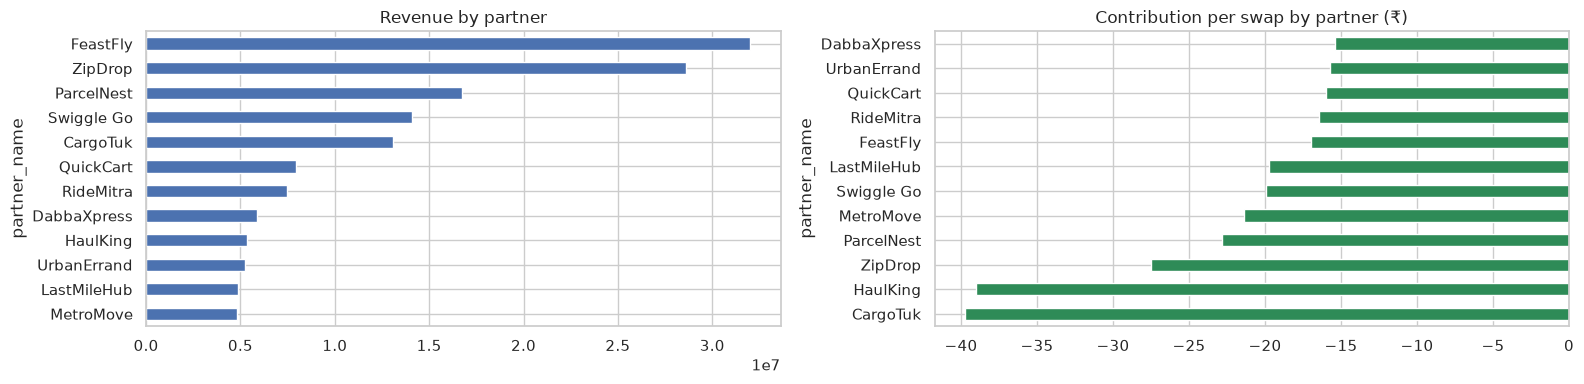

In [35]:
# Fleet partner economics
P = c[c.segment.astype(str) == "Fleet"].groupby("partner_id", observed=True).agg(
    swaps=("revenue", "size"), riders=("rider_id", "nunique"), revenue=("revenue", "sum"), rev_per_swap=("revenue", "mean"),
    discount_per_swap=("discount_inr", "mean"), energy=("energy_cost", "mean"), wear=("wear_v2", "mean"),
    station=("station_cost", "mean"), contrib_per_swap=("contrib_v2", "mean"), total_contrib=("contrib_v2", "sum"),
    peak_share=("hour", lambda s: s.isin(KEY["pilot"]["peak_hours"]).mean() * 100))
P = partners.set_index("partner_id")[["partner_name", "partner_segment", "vehicle_class", "contract_type", "discount_pct",
                                      "amendment_date", "discount_pct_after_amendment", "peak_surcharge_billable", "payment_terms_days"]].join(P)
P["revenue_share_%"] = P.revenue / P.revenue.sum() * 100
display(P.sort_values("revenue", ascending=False).round(2))
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
P.sort_values("revenue").plot.barh(x="partner_name", y="revenue", ax=ax[0], title="Revenue by partner", legend=False)
P.sort_values("contrib_per_swap").plot.barh(x="partner_name", y="contrib_per_swap", ax=ax[1], title="Contribution per swap by partner (₹)", legend=False, color="seagreen")
plt.tight_layout(); plt.show()

In [36]:
# Amended contracts: before vs after
for pid, row in partners[partners.amendment_date.notna()].set_index("partner_id").iterrows():
    x = c[c.partner_id.astype(str) == pid]
    ba = x.groupby(x.event_ts >= row.amendment_date).agg(swaps=("revenue", "size"), rev_per_swap=("revenue", "mean"),
                                                         contrib_per_swap=("contrib_v2", "mean"))
    ba["swaps_per_month"] = ba.swaps / x.groupby(x.event_ts >= row.amendment_date).month.nunique()
    ba.index = ["before", "after"][:len(ba)]
    print(f"==== {row.partner_name} ({pid}) amended {row.amendment_date.date()}: discount {row.discount_pct}% -> {row.discount_pct_after_amendment}%")
    display(ba.round(2))

==== ZipDrop (FP-03) amended 2024-11-01: discount 12.0% -> 28.0%


,swaps,rev_per_swap,contrib_per_swap,swaps_per_month
before,212882,57.480000,-19.06,21288.20
after,336167,48.639999,-32.88,42020.88


### 📝 Q5 findings — margin erosion comes from battery wear and one contract
- **Margin bridge (model v2):** the July 2024 price rise lifted contribution per swap from about **−₹16 to −₹8**, but from **Sep 2024** battery wear jumped **₹38 → ₹54 per swap** (Kyron) and ZipDrop's discount raised average discount **₹4.9 → ₹6.6**, pushing contribution back to about **−₹20**. *(Absolute values depend on the 70% end-of-life assumption; the direction and timing do not.)*
- **Peak pilot (Bengaluru & Pune, from 1 Oct 2024, peak 12–13h & 19–21h), difference-in-differences vs other cities:** peak-hour share **−2.6 pp**, peak not-served **+0.2 pp** (no service gain), revenue per swap **+₹5.1**. It works as a *revenue* lever, not a congestion fix. Fleet and independent riders shifted by similar small amounts.
- **Partners:** ZipDrop is the **largest partner by swaps** (549k) but has the **lowest 2W revenue/swap (₹52)** and the **worst 2W contribution (−₹27.5)**; its 28% discount (from Nov 2024) cut revenue/swap **₹57.5 → ₹48.6** while volume doubled. ZipDrop and Swiggle Go are not billed the peak surcharge although ~64–66% of their swaps are in peak hours. Best per-swap partners: DabbaXpress, UrbanErrand, QuickCart, RideMitra.

## Q6. Retention root cause (new riders)
**Definitions:** a *new rider* made their first completed swap between Jan 2024 and Apr 2025 (so everyone has ≥60 days of follow-up).
**Retained** = at least one completed swap on days 31–60 after the first swap. Early-experience features use the first 14 days.

New riders: 17,393 | 30-60 day retention: 86.9%


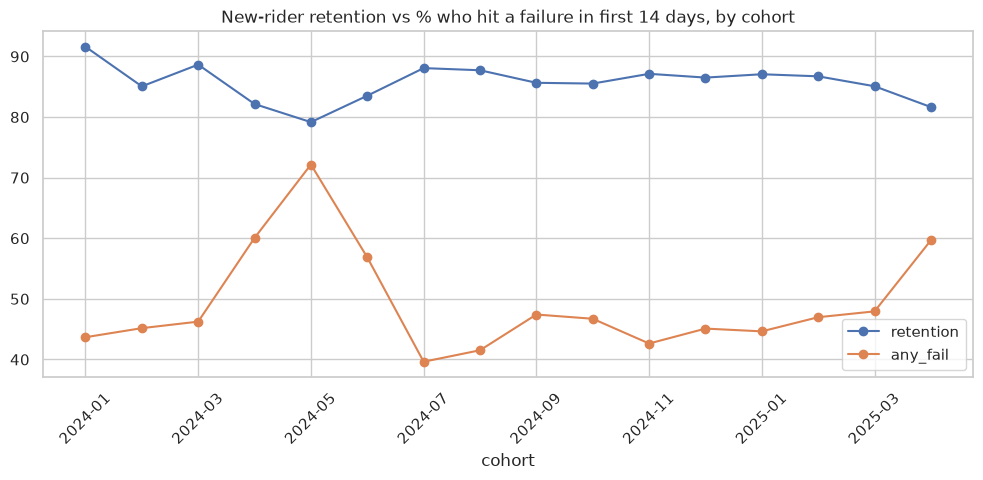

,riders,retention,any_fail
cohort,,,
2024-01,4179,91.6,43.7
2024-02,569,85.1,45.2
2024-03,599,88.6,46.2
2024-04,661,82.1,60.1
2024-05,715,79.2,72.2
2024-06,716,83.5,56.8
2024-07,805,88.1,39.6
2024-08,855,87.7,41.5
2024-09,871,85.6,47.4


In [37]:
first = sw[sw.completed].groupby("rider_id", observed=True).event_ts.min().rename("first_ts")
R = riders.set_index("rider_id").join(first, how="inner")
R = R[(R.first_ts >= "2024-01-01") & (R.first_ts < "2025-05-01")]
sw_r = sw[sw.rider_id.astype(str).isin(R.index)][["rider_id", "event_ts", "completed", "not_served", "stockout", "abandoned",
       "queue_wait_sec", "soh_out_pct", "station_id", "amount_charged_inr", "max_temp_c", "competitor_promo_active"]].copy()
sw_r["rider_id"] = sw_r.rider_id.astype(str)
sw_r = sw_r.merge(R.first_ts, left_on="rider_id", right_index=True)
sw_r["day"] = (sw_r.event_ts - sw_r.first_ts).dt.total_seconds() / 86400
e = sw_r[(sw_r.day >= -1) & (sw_r.day < 14)]
F = e.groupby("rider_id").agg(att_14d=("completed", "size"), fails_14d=("not_served", "sum"), stockouts_14d=("stockout", "sum"),
      wait_med_14d=("queue_wait_sec", "median"), wait_max_14d=("queue_wait_sec", "max"), soh_recv_14d=("soh_out_pct", "mean"),
      price_14d=("amount_charged_inr", "mean"), temp_14d=("max_temp_c", "mean"), promo_days_14d=("competitor_promo_active", "mean"))
ret = sw_r[(sw_r.day > 30) & (sw_r.day <= 60) & sw_r.completed].groupby("rider_id").size().gt(0).rename("retained")
R = R.join(F).join(ret); R["retained"] = R.retained.fillna(False).astype(bool)
fst = sw_r.sort_values("event_ts").groupby("rider_id").station_id.first().astype(str)
R["first_station"] = fst
st_rate = sw.groupby("station_id", observed=True).not_served.mean().mul(100); st_rate.index = st_rate.index.astype(str)
R["first_station_fail_%"] = R.first_station.map(st_rate)
R = R.join(stations.set_index("station_id")[["competitor_within_1_5km_since", "city", "charger_generation"]].rename(columns={"city": "station_city"}), on="first_station")
R["competitor_near_first_station"] = R.competitor_within_1_5km_since.notna() & (R.competitor_within_1_5km_since <= R.first_ts)
R["cohort"] = R.first_ts.dt.to_period("M").astype(str)
R["segment"] = np.where(R.partner_id.notna(), "Fleet", "Independent")
R["any_fail_14d"] = R.fails_14d > 0
R["summer_start"] = R.first_ts.dt.month.isin([4, 5, 6])
KEY["new_riders"] = len(R); KEY["retention_overall_%"] = round(R.retained.mean() * 100, 1)
print(f"New riders: {len(R):,} | 30-60 day retention: {R.retained.mean()*100:.1f}%")
coh = R.groupby("cohort").agg(riders=("retained", "size"), retention=("retained", "mean"), any_fail=("any_fail_14d", "mean"))
coh[["retention", "any_fail"]] *= 100
ax = coh[["retention", "any_fail"]].plot(marker="o", title="New-rider retention vs % who hit a failure in first 14 days, by cohort")
plt.xticks(rotation=45); plt.show(); display(coh.round(1))
KEY["retention_first3_last3_cohorts"] = [round(coh.retention.iloc[:3].mean(), 1), round(coh.retention.iloc[-3:].mean(), 1)]

,factor,best_level,worst_level,best_%,worst_%,gap_pp
3,soh_band,"(95, 101]","(0, 80]",88.2,77.6,10.6
0,fails_band,1,3+,88.2,79.7,8.4
6,summer_start,False,True,88.1,81.6,6.5
5,competitor_near_first_station,False,True,87.0,81.5,5.4
13,price_band,"(58.5, 65.0]","(21.666, 52.8]",88.4,84.4,4.0
14,charger_generation,Gen2,Gen3,87.9,84.0,3.9
7,station_city,Mumbai,Jaipur,88.8,85.0,3.8
2,wait_band,"(206.0, 234.0]","(53.999, 181.0]",88.5,84.7,3.8
4,first_station_fail_band,"(4.076, 4.596]","(7.84, 9.076]",88.7,85.0,3.7
10,vehicle_class,2W,3W,87.2,84.8,2.4


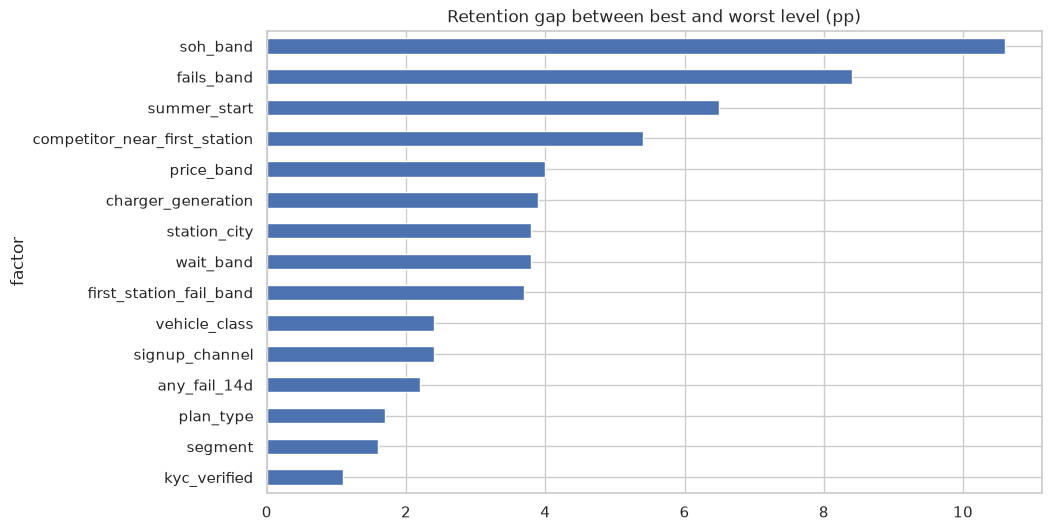

==== soh_band


,retention,riders
soh_band,,
"(0, 80]",77.6,366
"(80, 85]",85.7,1736
"(85, 90]",86.6,3108
"(90, 95]",86.3,5113
"(95, 101]",88.2,7070


==== fails_band


,retention,riders
fails_band,,
0,87.9,9083
1,88.2,5496
2,81.6,1940
3+,79.7,874


==== summer_start


,retention,riders
summer_start,,
False,88.1,14195
True,81.6,3198


==== competitor_near_first_station


,retention,riders
competitor_near_first_station,,
False,87.0,17155
True,81.5,238


In [38]:
# Univariate factor screen: retention by each factor, ranked by gap (pp)
R["fails_band"] = pd.cut(R.fails_14d, [-1, 0, 1, 2, 100], labels=["0", "1", "2", "3+"])
R["wait_band"] = pd.qcut(R.wait_med_14d, 4, duplicates="drop")
R["soh_band"] = pd.cut(R.soh_recv_14d, [0, 80, 85, 90, 95, 101])
R["first_station_fail_band"] = pd.qcut(R["first_station_fail_%"], 4, duplicates="drop")
R["price_band"] = pd.qcut(R.price_14d, 4, duplicates="drop")
factors = ["fails_band", "any_fail_14d", "wait_band", "soh_band", "first_station_fail_band", "competitor_near_first_station",
           "summer_start", "station_city", "signup_channel", "plan_type", "vehicle_class", "segment", "kyc_verified", "price_band", "charger_generation"]
rows = []
for f in factors:
    g = R.groupby(f, observed=True).retained.agg(["mean", "size"])
    g = g[g["size"] >= 30]
    if len(g) < 2: continue
    rows.append({"factor": f, "best_level": str(g["mean"].idxmax()), "worst_level": str(g["mean"].idxmin()),
                 "best_%": g["mean"].max() * 100, "worst_%": g["mean"].min() * 100, "gap_pp": (g["mean"].max() - g["mean"].min()) * 100})
screen = pd.DataFrame(rows).sort_values("gap_pp", ascending=False).round(1)
display(screen)
screen.plot.barh(x="factor", y="gap_pp", title="Retention gap between best and worst level (pp)", legend=False, figsize=(10, 6))
plt.gca().invert_yaxis(); plt.show()
for f in screen.factor.head(4):
    print(f"==== {f}"); display((R.groupby(f, observed=True).retained.agg(retention="mean", riders="size").assign(retention=lambda d: d.retention * 100)).round(1))

In [39]:
# Multivariate check: logistic regression (numpy, no extra installs) -> which factors survive controls?
X = pd.DataFrame({
    "fails_14d": R.fails_14d.fillna(0).clip(upper=5),
    "wait_med_min": R.wait_med_14d.fillna(R.wait_med_14d.median()) / 60,
    "soh_recv": R.soh_recv_14d.fillna(R.soh_recv_14d.median()),
    "first_station_fail_%": R["first_station_fail_%"].fillna(R["first_station_fail_%"].median()),
    "competitor_near": R.competitor_near_first_station.astype(float),
    "summer_start": R.summer_start.astype(float),
    "fleet": (R.segment == "Fleet").astype(float),
    "price_14d": R.price_14d.fillna(R.price_14d.median()),
    "promo_days_14d": R.promo_days_14d.fillna(0),
    "kyc": R.kyc_verified.astype(float),
})
X = pd.concat([X, pd.get_dummies(R.station_city, prefix="city", drop_first=True, dtype=float),
               pd.get_dummies(R.signup_channel, prefix="ch", drop_first=True, dtype=float),
               pd.get_dummies(R.vehicle_class, prefix="vc", drop_first=True, dtype=float)], axis=1)
mu, sd = X.mean(), X.std().replace(0, 1); Z = ((X - mu) / sd).to_numpy(); Z = np.c_[np.ones(len(Z)), Z]
y = R.retained.astype(float).to_numpy(); beta = np.zeros(Z.shape[1])
for _ in range(50):                      # Newton-Raphson with small ridge for stability
    p = 1 / (1 + np.exp(-Z @ beta)); W = p * (1 - p)
    H = Z.T @ (Z * W[:, None]) + 1e-3 * np.eye(Z.shape[1]); step = np.linalg.solve(H, Z.T @ (y - p) - 1e-3 * beta)
    beta += step
    if np.abs(step).max() < 1e-8: break
se = np.sqrt(np.diag(np.linalg.inv(H)))
coef = pd.DataFrame({"std_coef": beta[1:], "odds_ratio_per_1sd": np.exp(beta[1:]), "z": beta[1:] / se[1:]}, index=X.columns)
coef["abs_z"] = coef.z.abs(); coef = coef.sort_values("abs_z", ascending=False)
coef["role"] = np.select([coef.abs_z >= 8, coef.abs_z >= 3], ["PRIMARY", "secondary"], "weak / none")
display(coef.round(3))
KEY["retention_drivers"] = coef.head(6)[["odds_ratio_per_1sd", "z", "role"]].round(3).to_dict("index")

,std_coef,odds_ratio_per_1sd,z,abs_z,role
soh_recv,0.172,1.187,6.835,6.835,secondary
vc_3W,-0.414,0.661,-6.777,6.777,secondary
summer_start,-0.135,0.874,-6.103,6.103,secondary
price_14d,0.382,1.466,6.039,6.039,secondary
wait_med_min,-0.055,0.947,-2.493,2.493,weak / none
first_station_fail_%,-0.106,0.900,-2.333,2.333,weak / none
competitor_near,-0.037,0.964,-1.756,1.756,weak / none
city_Pune,-0.039,0.962,-1.403,1.403,weak / none
ch_referral,-0.032,0.968,-1.187,1.187,weak / none
city_Mumbai,0.032,1.032,1.078,1.078,weak / none


In [40]:
# Ticket text (optional): battery/range complaints hidden under generic categories
kw = r"range|battery|backup|jaldi|khatam|charge|km|dies|drain|pickup|not pulling"
tickets["text_battery"] = tickets.rider_comment.fillna("").str.lower().str.contains(kw)
tt = pd.crosstab(tickets.category, tickets.text_battery, normalize="index").mul(100).round(1)
display(tt.rename(columns={True: "% comments mention battery/range", False: "% other"}))
t30 = tickets.merge(R[["first_ts"]], left_on="rider_id", right_index=True)
t30 = t30[(t30.created_ts - t30.first_ts).dt.days.between(0, 30)]
R["ticket_30d"] = R.index.isin(t30.rider_id)
print("Retention by 'raised a ticket in first 30 days':", (R.groupby("ticket_30d").retained.mean() * 100).round(1).to_dict())

text_battery,% other,% comments mention battery/range
category,,
app_issue,100.0,0.0
billing_dispute,33.5,66.5
long_queue,100.0,0.0
low_range,11.6,88.4
no_battery_available,30.1,69.9
other,100.0,0.0


Retention by 'raised a ticket in first 30 days': {False: 85.9, True: 90.1}


### 📝 Q6 findings — why new riders don't return
- 17,393 new riders; **30–60 day retention 86.9%**, falling from **88.4%** (first 3 cohorts) to **84.5%** (last 3). Cohorts starting in **Apr–May** retain worst (79–82%) and 60–72% of them hit a failure in their first 14 days.
- **Primary drivers:**
  1. **Battery quality in the first 2 weeks** — riders who received packs averaging ≤80% SoH retain **77.6% vs 88.2%** (95%+); strongest factor in the multivariate model (z ≈ 6.8).
  2. **Early service failures, mostly heat-driven** — 2+ failures in first 14 days: **79.7–81.6% vs 88%**; summer starters: **81.6% vs 88.1%** (z ≈ −6.1). In the model, the summer effect absorbs the failure count (they move together).
- **Secondary / contributing:** 3W riders (odds ×0.66), a competitor within 1.5 km of the first station (81.5% vs 87.0%, small group), first station with a high failure rate, heavily discounted partner riders (low price band retains less).
- **Not drivers:** KYC status, signup channel, fleet vs independent, city (after controls).

## Key numbers summary (for the report)

In [41]:
import json
print(json.dumps(KEY, indent=2, default=str))

{
  "not_served_heat_alert_vs_not": {
    "false": 5.52,
    "true": 14.94
  },
  "share_failures_top10pct_stations": 24.1,
  "share_attempts_top10pct_stations": 17.2,
  "km_per_swap_first_last_month": {
    "2024-01": 71.69999694824219,
    "2025-06": 49.900001525878906
  },
  "contrib_v2_first3_last3": [
    -20.11,
    -18.45
  ],
  "pilot": {
    "cities": [
      "Bengaluru",
      "Pune"
    ],
    "start": "2024-10-01",
    "peak_hours": [
      12,
      13,
      19,
      20,
      21
    ]
  },
  "did_peak_share": -2.574,
  "did_peak_not_served": 0.211,
  "did_rev_per_swap": "5.132",
  "new_riders": 17393,
  "retention_overall_%": 86.9,
  "retention_first3_last3_cohorts": [
    88.4,
    84.5
  ],
  "retention_drivers": {
    "soh_recv": {
      "odds_ratio_per_1sd": 1.187,
      "z": 6.835,
      "role": "secondary"
    },
    "vc_3W": {
      "odds_ratio_per_1sd": 0.661,
      "z": -6.777,
      "role": "secondary"
    },
    "summer_start": {
      "odds_ratio_per_1sd": 0

---
# Conclusions & recommendations

**How the network performed:** strong growth (swaps +177%, revenue +200%) but service quality halved during summers and new-rider retention slipped from 88% to 85%; per-swap economics did not improve after the price rise.

**Primary drivers**
1. **Heat × old Gen1 chargers → slow charging → no charged battery.** Failures triple above 38°C, concentrated at Gen1 launch stations in Jaipur, Delhi NCR and Hyderabad.
2. **Kyron 2W battery cohort** → 3.2× faster degradation → shorter range, more swaps, higher wear cost (+₹16/swap) and worse new-rider retention.
3. **ZipDrop contract amendment** (28% discount, no peak surcharge) → largest partner is the least profitable.

**Secondary contributors:** 3W stock-outs, evening peak congestion, nearby competitors, first-station quality.

**Recommendations (answer to the budget question)**
| Proposal | Evidence says | Recommendation |
|---|---|---|
| More stations | Load does not predict failures; Wave 1 went to easy low-demand sites | **Instead upgrade Gen1 → Gen3 chargers + cabinet cooling at the ~15–20 worst hot-city stations before April** |
| More batteries | The problem is battery *quality*, not quantity | **Replace/stop Kyron 2W packs, add supplier QA on SoH-per-swap; add 3W inventory for summer** |
| Network-wide pricing | Pilot: +₹5/swap but only −2.6 pp peak shift, no service gain | **Keep as revenue lever in pilot cities; don't expect it to fix failures; bill peak surcharge to all partners** |
| Exclusive with largest partner | ZipDrop has the worst contribution per swap | **Do not sign; renegotiate discount to ~15% or tier it by off-peak share** |
| Extra | New riders churn after bad first 2 weeks | **"First 14 days" program: issue ≥90% SoH packs and route new riders to reliable stations** |

**Limitations:** observational data (associations, not proof of causation); battery wear uses an assumed 70% SoH end-of-life; synthetic dataset.

> *AI disclosure: analysis code and write-up were drafted with Claude (Anthropic) and reviewed by the team.*